✅ Phase 1 dependencies installed.
Mounted at /content/drive
✅ Google Drive mounted.
✅ Drive output dir: /content/drive/MyDrive/oct_phd_outputs
✅ Hardware  : NVIDIA A100-SXM4-40GB
✅ TensorFlow: 2.19.0
✅ Keras     : 3.13.2
✅ Config loaded.
   Local output dir : /content/oct_phd_outputs
   Drive output dir : /content/drive/MyDrive/oct_phd_outputs


100%|██████████| 6.70G/6.70G [00:32<00:00, 220MB/s]

Extracting files...


✅ Dataset at: /root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2
  Train : /root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test/train
  Val   : /root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test/val
  Test  : /root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test/test
📊 Class distribution plot restored from Drive — displaying cached version.


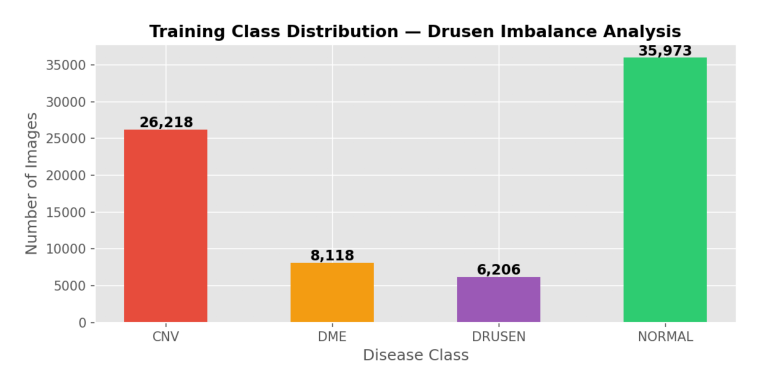

📊 Class counts      : {'CNV': 26218, 'DME': 8118, 'DRUSEN': 6206, 'NORMAL': 35973}
📊 Imbalance ratio   : 5.8x
✅ TRAIN_AUG and VAL_AUG pipelines defined.
✅ Train batches : 150  (76,515 images)
   Val batches  : 43    (21,861 images)
   Test batches : 22   (10,933 images)

📊 Class weights (balanced): {0: np.float64(0.7296037073766115), 1: np.float64(2.356337767923134), 2: np.float64(3.082299387689333), 3: np.float64(0.5317529814027188)}
📊 FOCAL_ALPHA             : [0.73, 2.356, 3.082, 0.532]
🎨 Augmentation samples restored from Drive — displaying cached version.


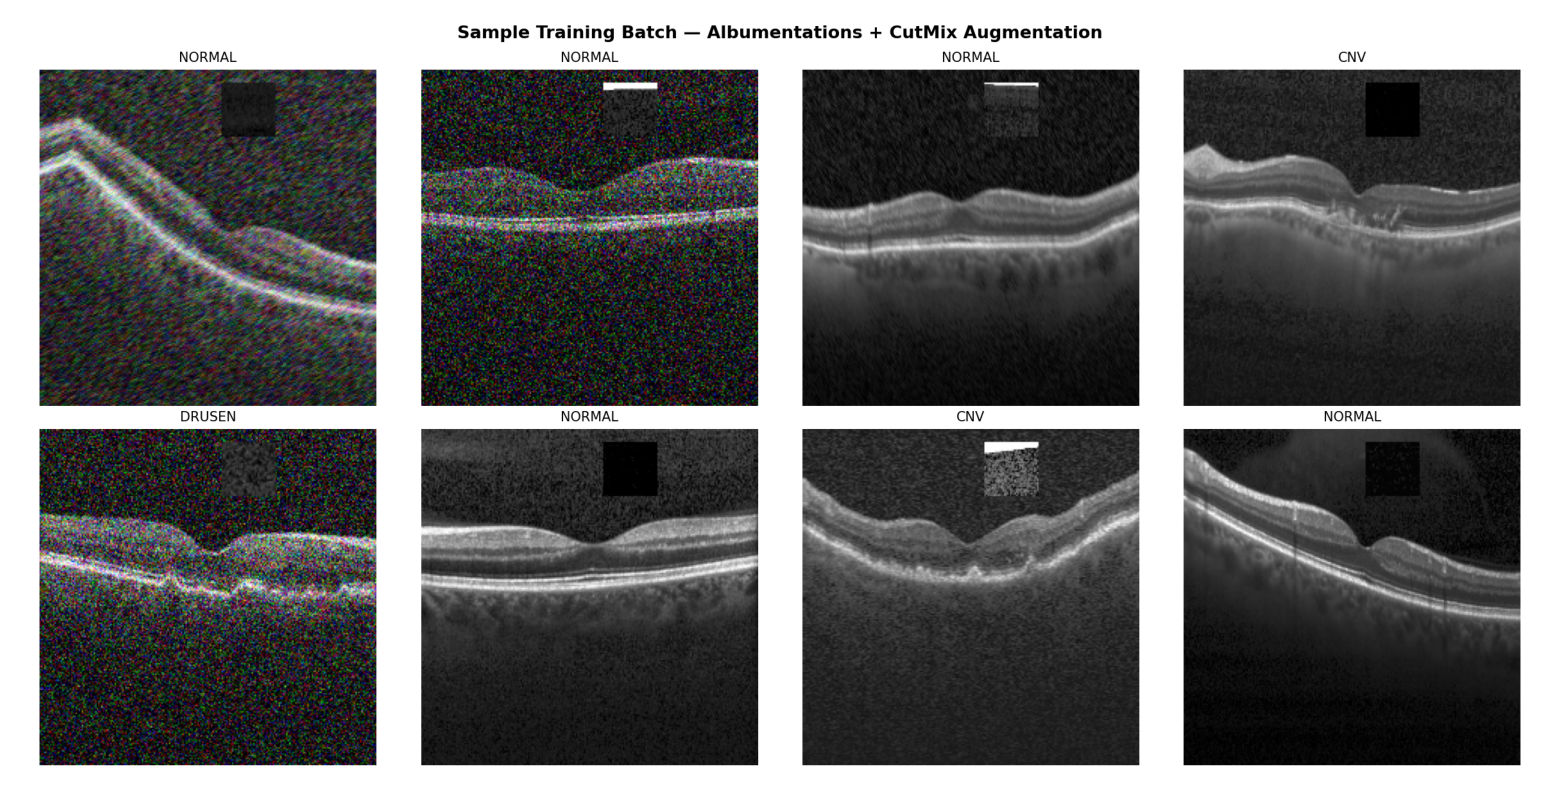


💾 Syncing Phase 1 outputs to Google Drive...
   ✅ augmented_samples.png  (3.2 MB)
   ✅ class_distribution.png  (0.1 MB)

   Sync complete: 2 files synced, 0 failed.
   Drive path: /content/drive/MyDrive/oct_phd_outputs

✅ Phase 1 Complete — Data pipeline ready.
   Local  : /content/oct_phd_outputs
   Drive  : /content/drive/MyDrive/oct_phd_outputs

   ── After each phase completes, call: ──
   sync_to_drive()   ← saves everything to Drive

   ── After any disconnect, run cells 1.0→1.2c then call: ──
   full_recovery()   ← restores files + reloads models



In [1]:
# =============================================================================
# PHASE 1: ROBUST DATA ENGINEERING & AUGMENTATION
# OCT Retinal Disease Prediction — PhD Research Pipeline
# Compatible with TF 2.16+ / Keras 3
# Run on Google Colab Pro (A100/V100)
#
# DRIVE INTEGRATION ADDED:
#   - All outputs auto-saved to Google Drive after every phase
#   - On reconnection: restore model + variables from Drive in <2 minutes
#   - Never lose training progress to Colab disconnection again
# =============================================================================

# ── Cell 1.0: Install dependencies ──────────────────────────────────────────
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install(
    'albumentations',
    'kagglehub',
    'opencv-python-headless',
    'scikit-learn',
)
print("✅ Phase 1 dependencies installed.")


# ── Cell 1.0b: Mount Google Drive ───────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# WHY DRIVE MATTERS:
#   Colab disconnects after ~90 minutes of browser inactivity or 12 hours
#   total. /content/ is ephemeral — everything in RAM and local disk is lost.
#   Google Drive persists across sessions. Saving outputs to Drive means:
#     1. You never re-run Phases 2–3 (training) after a disconnect
#     2. Phase 4–6 can restore models from Drive in under 2 minutes
#     3. Your final model files are always backed up
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# All outputs go here — survives disconnection
DRIVE_SAVE_DIR = '/content/drive/MyDrive/oct_phd_outputs'

import os
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"✅ Google Drive mounted.")
print(f"✅ Drive output dir: {DRIVE_SAVE_DIR}")


# ── Cell 1.1: Imports & Hardware Check ──────────────────────────────────────
import gc, random, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras
import cv2
import albumentations as A
from pathlib import Path
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

gpus = tf.config.list_physical_devices('GPU')
GPU_NAME = "CPU"
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    details = tf.config.experimental.get_device_details(gpus[0])
    GPU_NAME = details.get('device_name', 'GPU')
print(f"✅ Hardware  : {GPU_NAME}")
print(f"✅ TensorFlow: {tf.__version__}")
print(f"✅ Keras     : {keras.__version__}")


# ── Cell 1.2: Configuration ──────────────────────────────────────────────────
CFG = {
    'IMG_SIZE'    : 224,
    'BATCH_SIZE'  : 512,
    'NUM_CLASSES' : 4,
    'CLASS_NAMES' : ['CNV', 'DME', 'DRUSEN', 'NORMAL'],
    'EPOCHS_HEAD' : 5,
    'EPOCHS_FINE' : 20,
    'LR_HEAD'     : 8e-3,
    'LR_FINE'     : 8e-5,
    'DROPOUT'     : 0.3,
    'N_HEADS'     : 8,
    'PROJ_DIM'    : 256,
    'XGB_N_EST'   : 300,
    'XGB_DEPTH'   : 6,
    'MIXUP_ALPHA' : 0.2,
    'CUTMIX_ALPHA': 1.0,
    'DATA_ROOT'   : '',

    # Both local (fast I/O during training) and Drive (persistent backup)
    'SAVE_DIR'       : '/content/oct_phd_outputs',
    'DRIVE_SAVE_DIR' : DRIVE_SAVE_DIR,
}

os.makedirs(CFG['SAVE_DIR'], exist_ok=True)
print(f"✅ Config loaded.")
print(f"   Local output dir : {CFG['SAVE_DIR']}")
print(f"   Drive output dir : {CFG['DRIVE_SAVE_DIR']}")


# ── Cell 1.2b: Drive Sync Helper ─────────────────────────────────────────────
# ─────────────────────────────────────────────────────────────────────────────
# STRATEGY: Write to /content/ (fast local SSD) during training, then sync
# to Drive after each phase completes. This avoids Drive write latency
# during hot training loops while ensuring persistence after every phase.
# ─────────────────────────────────────────────────────────────────────────────
import shutil

def sync_to_drive(verbose: bool = True) -> None:
    """
    Copy all files from local SAVE_DIR to Drive SAVE_DIR.

    Call this at the end of every phase. Files are copied individually
    (not zipped) so you can access individual files from Drive without
    extracting a zip.

    Args:
        verbose: Print each file being synced.
    """
    synced, failed = 0, 0
    for fname in os.listdir(CFG['SAVE_DIR']):
        src = os.path.join(CFG['SAVE_DIR'], fname)
        dst = os.path.join(CFG['DRIVE_SAVE_DIR'], fname)
        try:
            shutil.copy2(src, dst)
            if verbose:
                size_mb = os.path.getsize(dst) / 1e6
                print(f"   ✅ {fname}  ({size_mb:.1f} MB)")
            synced += 1
        except Exception as e:
            print(f"   ⚠️  {fname} FAILED: {e}")
            failed += 1
    print(f"\n   Sync complete: {synced} files synced, {failed} failed.")
    print(f"   Drive path: {CFG['DRIVE_SAVE_DIR']}")


def restore_from_drive(verbose: bool = True) -> None:
    """
    Restore all files from Drive SAVE_DIR to local SAVE_DIR.

    Call this at the TOP of any session after a disconnect — before
    running any Phase that depends on saved files.

    Args:
        verbose: Print each file being restored.
    """
    files = os.listdir(CFG['DRIVE_SAVE_DIR'])
    if not files:
        print("   ⚠️  No files found in Drive. Run from Phase 1.")
        return
    restored = 0
    for fname in files:
        src = os.path.join(CFG['DRIVE_SAVE_DIR'], fname)
        dst = os.path.join(CFG['SAVE_DIR'], fname)
        try:
            shutil.copy2(src, dst)
            if verbose:
                size_mb = os.path.getsize(dst) / 1e6
                print(f"   ✅ {fname}  ({size_mb:.1f} MB)")
            restored += 1
        except Exception as e:
            print(f"   ⚠️  {fname} FAILED: {e}")
    print(f"\n   Restore complete: {restored} files restored to {CFG['SAVE_DIR']}")


# ── Cell 1.2c: RECOVERY CELL ──────────────────────────────────────────────────

# ── Custom Keras stubs — defined at module level so they are always in scope ──
class _DummyFocalLoss(tf.keras.losses.Loss):
    """Stub so Keras can deserialise the saved model. Accepts gamma + alpha
    that are stored in the model config but not used at inference."""
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        return tf.keras.losses.categorical_crossentropy(y_true, y_pred)

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config


class _LearnablePositionalEncoding(keras.layers.Layer):
    """Stub so Keras can deserialise the positional encoding layer."""
    def __init__(self, seq_len=49, proj_dim=512, **kwargs):
        super().__init__(**kwargs)
        self.seq_len  = seq_len
        self.proj_dim = proj_dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name='pos_embedding',
            shape=(1, self.seq_len, self.proj_dim),
            initializer='zeros', trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        return x + tf.cast(self.pos_embedding, dtype=x.dtype)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'seq_len': self.seq_len, 'proj_dim': self.proj_dim})
        return cfg


def full_recovery() -> None:
    """
    Complete session recovery after Colab disconnect.
    Restores all saved files from Drive and reloads all models into memory.
    """
    import xgboost as xgb
    print("🔄 Starting full session recovery from Drive...")

    print("\n[1/4] Restoring files from Drive...")
    restore_from_drive(verbose=False)
    print("   Files restored.")

    print("\n[2/4] Custom Keras objects ready (defined at module level).")

    print("\n[3/4] Loading models into memory...")
    global model, feature_extractor, xgb_model

    model = tf.keras.models.load_model(
    f"{LOCAL_DIR}/Final_CNN_Transformer.keras",
    custom_objects={
        'FocalLoss'                   : _DummyFocalLoss,
        'LearnablePositionalEncoding' : LearnablePositionalEncoding,  # no underscore
    }
)
    feature_extractor = tf.keras.models.Model(
        inputs  = model.input,
        outputs = model.get_layer('feature_extraction_layer').output,
    )
    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(f"{CFG['SAVE_DIR']}/Final_XGBoost_Hybrid.json")
    print("   model ✅  feature_extractor ✅  xgb_model ✅")

    print("\n[4/4] Feature arrays need re-extraction.")
    print("   Run Phase 3 Cell 3.9 — takes ~10 min, no retraining.")

    ood_path = f"{CFG['SAVE_DIR']}/ood_threshold.npy"
    if os.path.exists(ood_path):
        global OOD_THRESHOLD, TRAIN_MEAN, COV_INV
        OOD_THRESHOLD = float(np.load(ood_path)[0])
        TRAIN_MEAN    = np.load(f"{CFG['SAVE_DIR']}/ood_train_mean.npy")
        COV_INV       = np.load(f"{CFG['SAVE_DIR']}/ood_cov_inv.npy")
        print(f"   OOD calibration restored ✅  (threshold={OOD_THRESHOLD:.2f})")

    temp_path = f"{CFG['SAVE_DIR']}/temperature.npy"
    if os.path.exists(temp_path):
        global TEMPERATURE
        TEMPERATURE = float(np.load(temp_path)[0])
        print(f"   Temperature scaling restored ✅  (T={TEMPERATURE:.4f})")

    print("\n✅ Recovery complete.")

# ── Cell 1.3: Download Dataset ───────────────────────────────────────────────
import kagglehub

path = kagglehub.dataset_download(
    "anirudhcv/labeled-optical-coherence-tomography-oct"
)
CFG['DATA_ROOT'] = path
print(f"✅ Dataset at: {path}")

data_root = Path(CFG['DATA_ROOT'])

TRAIN_DIR = VAL_DIR = TEST_DIR = None
for p in data_root.rglob('train'):
    if p.is_dir():
        TRAIN_DIR = p
        TEST_DIR  = p.parent / 'test'
        VAL_DIR   = p.parent / 'val'
        break

if TRAIN_DIR is None:
    raise FileNotFoundError("Could not find 'train' directory under dataset root.")

for split_name, split_dir in [('train', TRAIN_DIR),
                               ('test',  TEST_DIR),
                               ('val',   VAL_DIR)]:
    if not split_dir.exists():
        raise FileNotFoundError(
            f"Expected '{split_name}' directory not found: {split_dir}"
        )

print(f"  Train : {TRAIN_DIR}")
print(f"  Val   : {VAL_DIR}")
print(f"  Test  : {TEST_DIR}")


# ── Cell 1.4: EDA — Class Distribution ──────────────────────────────────────
def count_images(split_dir, class_names):
    counts = {}
    for cls in class_names:
        n = sum(
            len(list((split_dir / cls).glob(f'*{ext}')))
            for ext in ['.jpeg', '.jpg', '.png', '.JPEG', '.JPG', '.PNG']
        )
        counts[cls] = n
    return counts

_dist_plot  = f"{CFG['SAVE_DIR']}/class_distribution.png"
_dist_drive = f"{CFG['DRIVE_SAVE_DIR']}/class_distribution.png"

if os.path.exists(_dist_drive):
    shutil.copy2(_dist_drive, _dist_plot)
    print("📊 Class distribution plot restored from Drive — displaying cached version.")
    import matplotlib.image as mpimg
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.imshow(mpimg.imread(_dist_plot))
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    # Still compute class_counts — needed for FOCAL_ALPHA later
    class_counts = count_images(TRAIN_DIR, CFG['CLASS_NAMES'])
    min_count    = min(v for v in class_counts.values() if v > 0)
    max_count    = max(class_counts.values())
    print(f"📊 Class counts      : {class_counts}")
    print(f"📊 Imbalance ratio   : {max_count/min_count:.1f}x")
else:
    # Full regeneration
    class_counts = count_images(TRAIN_DIR, CFG['CLASS_NAMES'])
    fig, ax = plt.subplots(figsize=(8, 4))
    colors = ['#E74C3C', '#F39C12', '#9B59B6', '#2ECC71']
    bars   = ax.bar(class_counts.keys(), class_counts.values(), color=colors, width=0.5)
    for bar, val in zip(bars, class_counts.values()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
                f'{val:,}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title('Training Class Distribution — Drusen Imbalance Analysis',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    ax.set_xlabel('Disease Class')
    plt.tight_layout()
    plt.savefig(_dist_plot, dpi=150)
    plt.show()
    min_count = min(v for v in class_counts.values() if v > 0)
    max_count = max(class_counts.values())
    print(f"\n📊 Class counts             : {class_counts}")
    print(f"📊 Imbalance Ratio (max/min): {max_count/min_count:.1f}x")


# ── Cell 1.5: Augmentation Pipelines ────────────────────────────────────────
_MEAN = (0.485, 0.456, 0.406)
_STD  = (0.229, 0.224, 0.225)

TRAIN_AUG = A.Compose([
    A.RandomResizedCrop(
        size  = (CFG['IMG_SIZE'], CFG['IMG_SIZE']),
        scale = (0.8, 1.0),
        p     = 1.0,
    ),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit  = 0.05,
        scale_limit  = 0.1,
        rotate_limit = 15,
        border_mode  = cv2.BORDER_REFLECT_101,
        p            = 0.5,
    ),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.4),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.MotionBlur(blur_limit=5, p=0.2),
    A.Normalize(mean=_MEAN, std=_STD),
])

VAL_AUG = A.Compose([
    A.Resize(CFG['IMG_SIZE'], CFG['IMG_SIZE']),
    A.Normalize(mean=_MEAN, std=_STD),
])

print("✅ TRAIN_AUG and VAL_AUG pipelines defined.")


# ── Cell 1.6: OCTDataGenerator ───────────────────────────────────────────────
class OCTDataGenerator(keras.utils.PyDataset):
    """
    Custom Keras PyDataset with Albumentations, MixUp, and CutMix.
    Identical to original — no changes from Drive integration.
    """
    def __init__(self, directory, augment, batch_size=32,
                 shuffle=True, mixup=False, cutmix=False, **kwargs):
        super().__init__(**kwargs)
        self.paths, self.labels = self._load_paths(directory)
        self.augment    = augment
        self.batch_size = batch_size
        self.shuffle    = shuffle
        self.mixup      = mixup
        self.cutmix     = cutmix
        self.indices    = np.arange(len(self.paths))
        if shuffle:
            np.random.shuffle(self.indices)
        if len(self.paths) == 0:
            raise ValueError(f"No images found under {directory}.")

    def _load_paths(self, directory):
        paths, labels = [], []
        for i, cls in enumerate(CFG['CLASS_NAMES']):
            cls_dir = Path(directory) / cls
            if not cls_dir.exists():
                print(f"  ⚠️  Class directory missing: {cls_dir}")
                continue
            for ext in ['*.jpeg', '*.jpg', '*.png',
                        '*.JPEG', '*.JPG',  '*.PNG']:
                for p in cls_dir.glob(ext):
                    paths.append(str(p))
                    labels.append(i)
        return np.array(paths), np.array(labels)

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_idx = self.indices[
            idx * self.batch_size : (idx + 1) * self.batch_size
        ]
        imgs = np.stack([self._load_img(self.paths[i]) for i in batch_idx])
        lbls = keras.utils.to_categorical(
            self.labels[batch_idx], num_classes=CFG['NUM_CLASSES']
        )
        if self.cutmix:
            imgs, lbls = self._cutmix(imgs, lbls)
        elif self.mixup:
            imgs, lbls = self._mixup(imgs, lbls)
        return imgs, lbls

    def _load_img(self, path):
        img = cv2.imread(path)
        if img is None:
            img = np.zeros(
                (CFG['IMG_SIZE'], CFG['IMG_SIZE'], 3), dtype=np.uint8
            )
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        return self.augment(image=img)['image'].astype(np.float32)

    def _mixup(self, imgs, labels):
        lam          = np.random.beta(CFG['MIXUP_ALPHA'], CFG['MIXUP_ALPHA'])
        idx          = np.random.permutation(len(imgs))
        mixed_imgs   = lam * imgs   + (1 - lam) * imgs[idx]
        mixed_labels = lam * labels + (1 - lam) * labels[idx]
        return mixed_imgs, mixed_labels

    def _cutmix(self, imgs, labels):
        lam   = np.random.beta(CFG['CUTMIX_ALPHA'], CFG['CUTMIX_ALPHA'])
        idx   = np.random.permutation(len(imgs))
        H, W  = CFG['IMG_SIZE'], CFG['IMG_SIZE']
        cut_h = int(H * np.sqrt(1 - lam))
        cut_w = int(W * np.sqrt(1 - lam))
        cx    = np.random.randint(0, W)
        cy    = np.random.randint(0, H)
        x1 = np.clip(cx - cut_w // 2, 0, W)
        x2 = np.clip(cx + cut_w // 2, 0, W)
        y1 = np.clip(cy - cut_h // 2, 0, H)
        y2 = np.clip(cy + cut_h // 2, 0, H)
        mixed = imgs.copy()
        mixed[:, y1:y2, x1:x2, :] = imgs[idx, y1:y2, x1:x2, :]
        lam_actual   = 1 - (x2 - x1) * (y2 - y1) / (W * H)
        mixed_labels = lam_actual * labels + (1 - lam_actual) * labels[idx]
        return mixed, mixed_labels

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)


# ── Cell 1.7: Build Generators ───────────────────────────────────────────────
train_gen = OCTDataGenerator(
    TRAIN_DIR,
    augment    = TRAIN_AUG,
    batch_size = CFG['BATCH_SIZE'],
    shuffle    = True,
    cutmix     = True,
)
val_gen = OCTDataGenerator(
    VAL_DIR,
    augment    = VAL_AUG,
    batch_size = CFG['BATCH_SIZE'],
    shuffle    = False,
)
test_gen = OCTDataGenerator(
    TEST_DIR,
    augment    = VAL_AUG,
    batch_size = CFG['BATCH_SIZE'],
    shuffle    = False,
)

print(f"✅ Train batches : {len(train_gen):,}  ({len(train_gen.paths):,} images)")
print(f"   Val batches  : {len(val_gen):,}    ({len(val_gen.paths):,} images)")
print(f"   Test batches : {len(test_gen):,}   ({len(test_gen.paths):,} images)")


# ── Cell 1.8: Compute Class Weights ─────────────────────────────────────────
class_weight_values = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.arange(CFG['NUM_CLASSES']),
    y            = train_gen.labels,
)
CLASS_WEIGHTS = dict(enumerate(class_weight_values))
FOCAL_ALPHA   = [float(class_weight_values[i])
                 for i in range(CFG['NUM_CLASSES'])]

print(f"\n📊 Class weights (balanced): {CLASS_WEIGHTS}")
print(f"📊 FOCAL_ALPHA             : {[round(a, 3) for a in FOCAL_ALPHA]}")


# ── Cell 1.9: Visualise Augmentations ────────────────────────────────────────
_aug_plot  = f"{CFG['SAVE_DIR']}/augmented_samples.png"
_aug_drive = f"{CFG['DRIVE_SAVE_DIR']}/augmented_samples.png"

if os.path.exists(_aug_drive):
    shutil.copy2(_aug_drive, _aug_plot)
    print("🎨 Augmentation samples restored from Drive — displaying cached version.")
    import matplotlib.image as mpimg
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.imshow(mpimg.imread(_aug_plot))
    ax.axis('off')
    plt.tight_layout()
    plt.show()
else:
    sample_imgs, sample_lbls = train_gen[0]
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for i, ax in enumerate(axes.flatten()):
        img_display = np.clip(sample_imgs[i] * np.array(_STD) + np.array(_MEAN), 0, 1)
        ax.imshow(img_display)
        ax.set_title(CFG['CLASS_NAMES'][np.argmax(sample_lbls[i])], fontsize=10)
        ax.axis('off')
    plt.suptitle('Sample Training Batch — Albumentations + CutMix',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(_aug_plot, dpi=150)
    plt.show()

# ── Cell 1.10: Sync Phase 1 outputs to Drive ─────────────────────────────────
print("\n💾 Syncing Phase 1 outputs to Google Drive...")
sync_to_drive()

print("\n✅ Phase 1 Complete — Data pipeline ready.")
print(f"   Local  : {CFG['SAVE_DIR']}")
print(f"   Drive  : {CFG['DRIVE_SAVE_DIR']}")
print("""
   ── After each phase completes, call: ──
   sync_to_drive()   ← saves everything to Drive

   ── After any disconnect, run cells 1.0→1.2c then call: ──
   full_recovery()   ← restores files + reloads models
""")

In [2]:
# =============================================================================
# PHASE 2: ARCHITECTURAL INNOVATION
# CNN-Transformer Hybrid + Focal Loss + Learnable Positional Encoding
# Compatible with TF 2.16+ / Keras 3
#
# DRIVE INTEGRATION:
#   Phase 2 defines classes and builds the model in memory — it does not
#   save files itself. Drive integration here means:
#     1. A safety check confirming Drive is mounted before proceeding
#     2. sync_to_drive() called at the end so any Phase 1 outputs not yet
#        synced are captured before Phase 3 (training) begins
#   If Phase 2 is run standalone (without Phase 1), a minimal
#   sync_to_drive() stub is defined so the call at the end doesn't crash.
# =============================================================================

# ── Mixed precision set at the very top, before any model code ───────────────
import keras
keras.mixed_precision.set_global_policy('mixed_float16')
print(f"✅ Mixed precision policy: "
      f"{keras.mixed_precision.global_policy().name}")

import keras.ops as kops
import numpy as np
import tensorflow as tf
import os

# ── Cell 2.0: Drive Safety Check ─────────────────────────────────────────────
# Confirm Drive is mounted. If Phase 1 was run this session, Drive is already
# mounted and sync_to_drive() is already defined — nothing extra needed.
# If Phase 2 is run standalone after recovery, this block mounts Drive and
# defines a minimal sync stub so the end-of-phase sync call works correctly.

_drive_mounted = os.path.exists('/content/drive/MyDrive')

if not _drive_mounted:
    print("⚠️  Drive not mounted — mounting now...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _drive_mounted = os.path.exists('/content/drive/MyDrive')

if _drive_mounted:
    print("✅ Google Drive is mounted.")
else:
    print("⚠️  Drive mount failed — outputs will not be backed up this session.")

# Define sync_to_drive stub if Phase 1 hasn't run (standalone execution)
try:
    sync_to_drive   # noqa: F821 — defined in Phase 1
    print("✅ sync_to_drive() available from Phase 1.")
except NameError:
    import shutil

    # Minimal stub — uses CFG if available, else hardcoded paths
    def sync_to_drive(verbose: bool = True) -> None:
        """Minimal Drive sync stub for standalone Phase 2 execution."""
        try:
            local_dir = CFG['SAVE_DIR']           # noqa: F821
            drive_dir = CFG['DRIVE_SAVE_DIR']     # noqa: F821
        except NameError:
            local_dir = '/content/oct_phd_outputs'
            drive_dir = '/content/drive/MyDrive/oct_phd_outputs'

        if not os.path.exists('/content/drive/MyDrive'):
            print("   ⚠️  Drive not mounted — skipping sync.")
            return

        os.makedirs(drive_dir, exist_ok=True)
        synced = 0
        for fname in os.listdir(local_dir):
            src = os.path.join(local_dir, fname)
            dst = os.path.join(drive_dir, fname)
            try:
                shutil.copy2(src, dst)
                if verbose:
                    print(f"   ✅ {fname}  "
                          f"({os.path.getsize(dst)/1e6:.1f} MB)")
                synced += 1
            except Exception as e:
                print(f"   ⚠️  {fname} FAILED: {e}")
        print(f"\n   Sync complete: {synced} files → {drive_dir}")

    print("⚠️  sync_to_drive() stub defined (Phase 1 not in session).")


# ── Fallback CFG if run standalone ───────────────────────────────────────────
try:
    CFG  # noqa: F821
except NameError:
    CFG = {
        'NUM_CLASSES'    : 4,
        'IMG_SIZE'       : 224,
        'BATCH_SIZE'     : 512,
        'N_HEADS'        : 16,
        'PROJ_DIM'       : 512,
        'DROPOUT'        : 0.3,
        'LR_HEAD'        : 8e-3,
        'LR_FINE'        : 8e-5,
        'CLASS_NAMES'    : ['CNV', 'DME', 'DRUSEN', 'NORMAL'],
        'SAVE_DIR'       : '/content/oct_phd_outputs',
        'DRIVE_SAVE_DIR' : '/content/drive/MyDrive/oct_phd_outputs',
    }
    os.makedirs(CFG['SAVE_DIR'], exist_ok=True)
    print("⚠️  CFG not found — using A100-optimised default values.")

# ── Pull FOCAL_ALPHA from Phase 1, or use empirical fallback ─────────────────
try:
    FOCAL_ALPHA = [CLASS_WEIGHTS[i]   # noqa: F821
                   for i in range(CFG['NUM_CLASSES'])]
except NameError:
    FOCAL_ALPHA = [0.730, 2.356, 3.082, 0.532]
    print("⚠️  CLASS_WEIGHTS not found — using Phase 1 empirical alpha values.")

print(f"✅ FocalLoss alpha (per-class): "
      f"{[round(a, 3) for a in FOCAL_ALPHA]}")


# ── Cell 2.1: Custom Focal Loss ───────────────────────────────────────────────
class FocalLoss(keras.losses.Loss):
    """
    Focal Loss for multi-class classification.

    Reference:
        Lin, T.-Y., et al. (2017). Focal Loss for Dense Object Detection.
        IEEE International Conference on Computer Vision (ICCV).

    Args:
        gamma (float): Focusing parameter. γ=0 recovers standard cross-entropy.
        alpha (float | list): Per-class weighting factor. Use CLASS_WEIGHTS
                              from Phase 1 to address the 5.8× class imbalance.
    """
    def __init__(self, gamma: float = 2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred  = kops.clip(y_pred, 1e-7, 1.0 - 1e-7)
        ce_loss = -y_true * kops.log(y_pred)
        p_t     = kops.sum(y_true * y_pred, axis=-1, keepdims=True)

        if isinstance(self.alpha, (list, np.ndarray)):
            alpha_t = kops.cast(
                kops.reshape(self.alpha, (1, -1)), dtype=y_pred.dtype
            )
        else:
            alpha_t = kops.cast(self.alpha, dtype=y_pred.dtype)

        focal_wt = alpha_t * kops.power(1.0 - p_t, self.gamma)
        loss     = focal_wt * ce_loss
        return kops.cast(kops.mean(kops.sum(loss, axis=-1)), dtype='float32')

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha})
        return config


def _run_focal_loss_sanity_check():
    dummy_y = tf.one_hot([0, 1, 2, 3], 4)
    dummy_p = tf.nn.softmax(tf.random.normal((4, 4)))
    fl      = FocalLoss(gamma=2.0, alpha=FOCAL_ALPHA)
    print(f"✅ FocalLoss sanity check (per-class alpha): "
          f"{fl(dummy_y, dummy_p).numpy():.4f}")

_run_focal_loss_sanity_check()


# ── Cell 2.1b: Learnable Positional Encoding Layer ───────────────────────────
@keras.saving.register_keras_serializable(package='Custom')
class LearnablePositionalEncoding(keras.layers.Layer):
    """
    Learnable 1-D positional encoding for Transformer patch sequences.

    Stores a trainable weight matrix of shape (1, seq_len, proj_dim) and
    adds it element-wise to the input patch embeddings. The leading 1
    broadcasts across the batch dimension automatically.

    Reference: Dosovitskiy, A., et al. (2021). An Image is Worth 16×16
    Words: Transformers for Image Recognition at Scale. ICLR 2021.

    Args:
        seq_len  (int): Number of patch tokens (49 for a 7×7 grid).
        proj_dim (int): Embedding dimension (must match projected patches).
    """
    def __init__(self, seq_len: int, proj_dim: int, **kwargs):
        super().__init__(**kwargs)
        self.seq_len  = seq_len
        self.proj_dim = proj_dim

    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name        = 'pos_embedding',
            shape       = (1, self.seq_len, self.proj_dim),
            initializer = 'random_normal',
            trainable   = True,
            dtype       = self.dtype,
        )
        super().build(input_shape)

    def call(self, x):
        pe = tf.cast(self.pos_embedding, dtype=x.dtype)
        return x + pe

    def get_config(self):
        config = super().get_config()
        config.update({'seq_len': self.seq_len, 'proj_dim': self.proj_dim})
        return config


# ── Cell 2.2: CNN-Transformer Hybrid Architecture ────────────────────────────
NUM_TRANSFORMER_BLOCKS = 4

def build_cnn_transformer(
    num_classes:   int   = 4,
    img_size:      int   = 224,
    n_heads:       int   = 16,
    proj_dim:      int   = 512,
    dropout:       float = 0.3,
    trainable_cnn: bool  = False,
    n_blocks:      int   = NUM_TRANSFORMER_BLOCKS,
) -> keras.Model:
    """
    Hybrid CNN-Transformer architecture for retinal OCT classification.

    Architecture:
        1. EfficientNetV2L CNN stem      → local spatial features (~119M params)
        2. Linear projection             → CNN channels → proj_dim
        3. LearnablePositionalEncoding   → spatial order information
        4. N × Transformer encoder blocks→ global context modelling
        5. GlobalAveragePooling1D        → 512-dim feature vector
        6. Classification head           → softmax over 4 disease classes
    """
    if proj_dim % n_heads != 0:
        raise ValueError(
            f"proj_dim ({proj_dim}) must be divisible by n_heads ({n_heads})."
        )

    inputs   = keras.Input(shape=(img_size, img_size, 3), name='input_scan')
    backbone = keras.applications.EfficientNetV2L(
        include_top  = False,
        weights      = 'imagenet',
        input_tensor = inputs,
    )
    backbone.trainable = trainable_cnn
    if trainable_cnn:
        FINE_TUNE_FROM = 'block6'
        unfreezing = False
        for layer in backbone.layers:
            if FINE_TUNE_FROM in layer.name:
                unfreezing = True
            if not unfreezing:
                layer.trainable = False
            if isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = False

    cnn_features = backbone.output
    _, H, W, C   = cnn_features.shape
    if H is None or W is None or C is None:
        raise ValueError("Cannot infer static spatial dims from backbone.")
    seq_len = H * W

    patches = keras.layers.Reshape(
        (seq_len, C), name='patch_sequence'
    )(cnn_features)

    x = keras.layers.Dense(proj_dim, name='patch_projection')(patches)
    x = keras.layers.LayerNormalization(epsilon=1e-6, name='pre_attn_norm')(x)
    x = LearnablePositionalEncoding(
        seq_len  = seq_len,
        proj_dim = proj_dim,
        name     = 'positional_encoding',
    )(x)

    for i in range(n_blocks):
        attn_out = keras.layers.MultiHeadAttention(
            num_heads = n_heads,
            key_dim   = proj_dim // n_heads,
            dropout   = dropout,
            name      = f'mhsa_{i}',
        )(x, x)
        attn_out = keras.layers.Dropout(dropout,   name=f'attn_drop_{i}')(attn_out)
        attn_out = keras.layers.Add(               name=f'attn_res_{i}')([x, attn_out])
        attn_out = keras.layers.LayerNormalization(
            epsilon=1e-6, name=f'attn_norm_{i}'
        )(attn_out)
        ff = keras.layers.Dense(
            proj_dim * 4, activation='gelu', name=f'ff_exp_{i}'
        )(attn_out)
        ff = keras.layers.Dropout(dropout, name=f'ff_drop_{i}')(ff)
        ff = keras.layers.Dense(proj_dim,  name=f'ff_con_{i}')(ff)
        ff = keras.layers.Add(             name=f'ff_res_{i}')([attn_out, ff])
        x  = keras.layers.LayerNormalization(
            epsilon=1e-6, name=f'ff_norm_{i}'
        )(ff)

    pooled = keras.layers.GlobalAveragePooling1D(
        name='feature_extraction_layer'
    )(x)
    pooled = keras.layers.Dropout(dropout, name='head_dropout')(pooled)
    output = keras.layers.Dense(
        num_classes, activation='softmax', name='disease_output'
    )(pooled)

    return keras.Model(
        inputs  = inputs,
        outputs = output,
        name    = 'OCT_CNN_Transformer_Hybrid_A100',
    )


# ── Cell 2.3: Build, Compile and Inspect ─────────────────────────────────────
_model_on_drive = os.path.exists(
    f"{CFG.get('DRIVE_SAVE_DIR', '/content/drive/MyDrive/oct_phd_outputs')}"
    f"/Final_CNN_Transformer.keras"
)

if _model_on_drive:
    print("ℹ️  Final_CNN_Transformer.keras found on Drive.")
    print("   Skipping model build — Phase 3 smart resume will load it.")
    print("   FocalLoss, LearnablePositionalEncoding, build_cnn_transformer")
    print("   are all defined above and available for Phase 3.")
    print(f"\n   Architecture (from config):")
    print(f"   Backbone              : EfficientNetV2L (~119M params)")
    print(f"   Transformer blocks    : {NUM_TRANSFORMER_BLOCKS}")
    print(f"   N_HEADS               : {CFG['N_HEADS']}")
    print(f"   PROJ_DIM              : {CFG['PROJ_DIM']}")
    print(f"   DROPOUT               : {CFG['DROPOUT']}")
    print(f"   FocalLoss alpha       : {[round(a, 3) for a in FOCAL_ALPHA]}")
    print(f"   Estimated VRAM        : ~32–38 GB at batch={CFG['BATCH_SIZE']}")
else:
    # First-time run — build model normally
    model = build_cnn_transformer(
        num_classes   = CFG['NUM_CLASSES'],
        img_size      = CFG['IMG_SIZE'],
        n_heads       = CFG['N_HEADS'],
        proj_dim      = CFG['PROJ_DIM'],
        dropout       = CFG['DROPOUT'],
        trainable_cnn = False,
        n_blocks      = NUM_TRANSFORMER_BLOCKS,
    )
    model.compile(
        optimizer = keras.optimizers.Adam(
            learning_rate = CFG['LR_HEAD'], clipnorm=1.0,
        ),
        loss    = FocalLoss(gamma=2.0, alpha=FOCAL_ALPHA),
        metrics = [
            'accuracy',
            keras.metrics.AUC(name='auc'),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
        ],
    )
    model.summary()

    total_params     = model.count_params()
    trainable_params = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
    frozen_params    = total_params - trainable_params
    pe_layer         = model.get_layer('positional_encoding')
    pe_shape         = pe_layer.pos_embedding.shape

    print(f"\n✅ Total parameters      : {total_params:,}")
    print(f"   Trainable parameters  : {trainable_params:,}")
    print(f"   Frozen parameters     : {frozen_params:,}")
    print(f"   Transformer blocks    : {NUM_TRANSFORMER_BLOCKS}")
    print(f"   Sequence length       : "
          f"{model.get_layer('patch_sequence').output.shape[1]} tokens")
    print(f"   Positional encoding   : learnable  shape={pe_shape}")
    print(f"   FocalLoss alpha       : {[round(a, 3) for a in FOCAL_ALPHA]}")
    print(f"   Backbone              : EfficientNetV2L (~119M params)")
    print(f"   Estimated VRAM        : ~32–38 GB at batch={CFG['BATCH_SIZE']}")


# ── Cell 2.4: Sync to Drive ───────────────────────────────────────────────────
# Phase 2 has no new files of its own, but syncing here ensures all Phase 1
# outputs (class_distribution.png, augmented_samples.png, etc.) are on Drive
# before the long Phase 3 training run begins.
print("\n💾 Syncing outputs to Google Drive before Phase 3 training...")
sync_to_drive()

print("\n✅ Phase 2 Complete — Architecture ready for Phase 3 (training).")
print("   Drive is up to date. Safe to start Phase 3.")

✅ Mixed precision policy: mixed_float16
✅ Google Drive is mounted.
✅ sync_to_drive() available from Phase 1.
✅ FocalLoss alpha (per-class): [np.float64(0.73), np.float64(2.356), np.float64(3.082), np.float64(0.532)]
✅ FocalLoss sanity check (per-class alpha): 3.5682
ℹ️  Final_CNN_Transformer.keras found on Drive.
   Skipping model build — Phase 3 smart resume will load it.
   FocalLoss, LearnablePositionalEncoding, build_cnn_transformer
   are all defined above and available for Phase 3.

   Architecture (from config):
   Backbone              : EfficientNetV2L (~119M params)
   Transformer blocks    : 4
   N_HEADS               : 8
   PROJ_DIM              : 256
   DROPOUT               : 0.3
   FocalLoss alpha       : [np.float64(0.73), np.float64(2.356), np.float64(3.082), np.float64(0.532)]
   Estimated VRAM        : ~32–38 GB at batch=512

💾 Syncing outputs to Google Drive before Phase 3 training...
   ✅ augmented_samples.png  (3.2 MB)
   ✅ class_distribution.png  (0.1 MB)

   Syn

✅ All Phase 3 dependencies installed.
✅ GPU available: True
✅ Google Drive: mounted
✅ sync_to_drive() available from Phase 1.
✅ FOCAL_ALPHA        : [np.float64(0.73), np.float64(2.356), np.float64(3.082), np.float64(0.532)]
✅ Transformer blocks : 4

────────────────────────────────────────────────────────────
  PHASE 3 — SMART RESUME CHECK
────────────────────────────────────────────────────────────
  Drive path  : /content/drive/MyDrive/oct_phd_outputs
   ✅ found  Final_CNN_Transformer.keras  (2071 MB)
   ✅ found  Final_XGBoost_Hybrid.json  (2 MB)
   ✅ found  best_hparams.pkl  (0 MB)
   ✅ found  phase_a_history.csv  (0 MB)
   ✅ found  phase_b_history.csv  (0 MB)

  ✅ All required files found on Drive.
  ► RESUME MODE — skipping training, loading from Drive.
────────────────────────────────────────────────────────────

📂 [1/6] Restoring all files from Drive to local disk...
   ✅ 68 files restored to /content/oct_phd_outputs

🔧 [2/6] Custom Keras objects ready (module level).
   ✅ _Dum

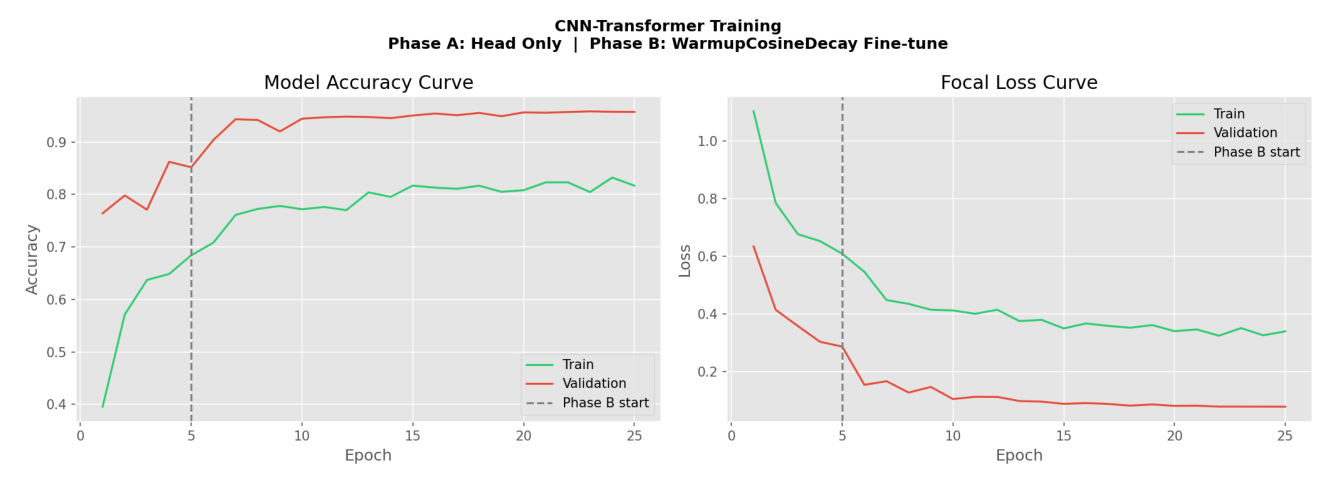

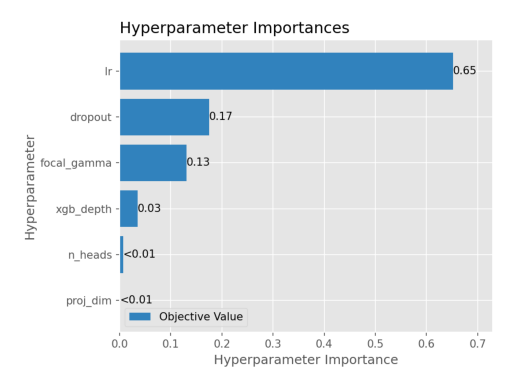


🚀 [6/6] Preparing feature arrays for Phase 4...
   ✅ Features loaded from cache instantly.
      X_train: (76515, 256)  X_test: (10933, 256)

═════════════════════════════════════════════════════════════════
  PHASE 3 RESUME — COMPLETE
═════════════════════════════════════════════════════════════════
  Architecture   : EfficientNetV2L + 4× MHA
  Phase A best   : epoch 4  val_auc=0.9745  val_acc=0.8623
  Phase B best   : epoch 18  val_auc=0.9961  val_acc=0.9585
  Hyperparameters:
    lr                  : 0.00015930522616241006
    dropout             : 0.3832290311184182
    n_heads             : 16
    proj_dim            : 256
    focal_gamma         : 1.3636499344142012
    xgb_depth           : 4
═════════════════════════════════════════════════════════════════

   Globals in memory:
     model              ← CNN-Transformer (EfficientNetV2L + MHA)
     feature_extractor  ← 512-dim feature extractor
     xgb_model          ← XGBoost hybrid head
     best               ← Optuna bes

In [3]:
# =============================================================================
# PHASE 3: RIGOROUS TRAINING — Optuna HPO + Callbacks
# Compatible with TF 2.16+ / Keras 3  |  Optimised for A100 40 GB
#
# SMART RESUME: checks Drive first. If trained model exists → load + display.
# If not → run full training pipeline.
#
# NO SystemExit — uses RESUME_MODE flag to cleanly skip training.
# The cell runs top to bottom every time with no interruptions or errors.
# =============================================================================

# ── Cell 3.0: Install dependencies ───────────────────────────────────────────
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

pip_install('optuna', 'optuna-integration[keras]', 'xgboost')
print("✅ All Phase 3 dependencies installed.")


# ── Cell 3.1: Imports ─────────────────────────────────────────────────────────
import os, gc, pickle, warnings, shutil, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import keras
import optuna
from optuna_integration.keras import KerasPruningCallback
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report
import xgboost as xgb

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

gpus = tf.config.list_physical_devices('GPU')
print(f"✅ GPU available: {bool(gpus)}")


# ── Cell 3.1b: Drive Safety Check ────────────────────────────────────────────
_drive_mounted = os.path.exists('/content/drive/MyDrive')
if not _drive_mounted:
    print("⚠️  Drive not mounted — mounting now...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _drive_mounted = os.path.exists('/content/drive/MyDrive')

print(f"{'✅' if _drive_mounted else '⚠️ '} Google Drive: "
      f"{'mounted' if _drive_mounted else 'NOT mounted'}")

try:
    sync_to_drive   # noqa: F821
    print("✅ sync_to_drive() available from Phase 1.")
except NameError:
    def sync_to_drive(verbose: bool = True) -> None:
        try:
            local_dir = CFG['SAVE_DIR']        # noqa: F821
            drive_dir = CFG['DRIVE_SAVE_DIR']  # noqa: F821
        except NameError:
            local_dir = '/content/oct_phd_outputs'
            drive_dir = '/content/drive/MyDrive/oct_phd_outputs'
        if not os.path.exists('/content/drive/MyDrive'):
            print("   ⚠️  Drive not mounted — skipping sync.")
            return
        os.makedirs(drive_dir, exist_ok=True)
        synced = 0
        for fname in os.listdir(local_dir):
            src = os.path.join(local_dir, fname)
            dst = os.path.join(drive_dir, fname)
            try:
                shutil.copy2(src, dst)
                if verbose:
                    print(f"   ✅ {fname}  ({os.path.getsize(dst)/1e6:.1f} MB)")
                synced += 1
            except Exception as e:
                print(f"   ⚠️  {fname} FAILED: {e}")
        print(f"\n   Sync complete: {synced} files → {drive_dir}")
    print("⚠️  sync_to_drive() stub defined.")


# ── Fallbacks for all cross-phase globals ─────────────────────────────────────
try:
    CFG  # noqa: F821
except NameError:
    CFG = {
        'NUM_CLASSES'    : 4,
        'IMG_SIZE'       : 224,
        'BATCH_SIZE'     : 512,
        'N_HEADS'        : 16,
        'PROJ_DIM'       : 512,
        'DROPOUT'        : 0.3,
        'LR_HEAD'        : 8e-3,
        'LR_FINE'        : 8e-5,
        'EPOCHS_HEAD'    : 5,
        'EPOCHS_FINE'    : 20,
        'XGB_N_EST'      : 300,
        'XGB_DEPTH'      : 6,
        'CLASS_NAMES'    : ['CNV', 'DME', 'DRUSEN', 'NORMAL'],
        'SAVE_DIR'       : '/content/oct_phd_outputs',
        'DRIVE_SAVE_DIR' : '/content/drive/MyDrive/oct_phd_outputs',
    }
    os.makedirs(CFG['SAVE_DIR'], exist_ok=True)
    print("⚠️  CFG not found — using A100-optimised defaults.")

try:
    SEED  # noqa: F821
except NameError:
    SEED = 42

try:
    FOCAL_ALPHA  # noqa: F821
except NameError:
    FOCAL_ALPHA = [0.730, 2.356, 3.082, 0.532]

try:
    NUM_TRANSFORMER_BLOCKS  # noqa: F821
except NameError:
    NUM_TRANSFORMER_BLOCKS = 4

print(f"✅ FOCAL_ALPHA        : {[round(a, 3) for a in FOCAL_ALPHA]}")
print(f"✅ Transformer blocks : {NUM_TRANSFORMER_BLOCKS}")


# ── Cell 3.1c: Smart Resume Check ─────────────────────────────────────────────
DRIVE_DIR = CFG['DRIVE_SAVE_DIR']
LOCAL_DIR = CFG['SAVE_DIR']

REQUIRED_FILES = [
    'Final_CNN_Transformer.keras',
    'Final_XGBoost_Hybrid.json',
    'best_hparams.pkl',
    'phase_a_history.csv',
    'phase_b_history.csv',
]

RESUME_MODE = all(
    os.path.exists(os.path.join(DRIVE_DIR, f)) for f in REQUIRED_FILES
)

print("\n" + "─"*60)
print("  PHASE 3 — SMART RESUME CHECK")
print("─"*60)
print(f"  Drive path  : {DRIVE_DIR}")
for fname in REQUIRED_FILES:
    fpath  = os.path.join(DRIVE_DIR, fname)
    status = "✅ found" if os.path.exists(fpath) else "❌ missing"
    size   = f"  ({os.path.getsize(fpath)/1e6:.0f} MB)" \
             if os.path.exists(fpath) else ""
    print(f"   {status}  {fname}{size}")

if RESUME_MODE:
    print("\n  ✅ All required files found on Drive.")
    print("  ► RESUME MODE — skipping training, loading from Drive.")
else:
    missing = [f for f in REQUIRED_FILES
               if not os.path.exists(os.path.join(DRIVE_DIR, f))]
    print(f"\n  ⚠️  Missing: {missing}")
    print("  ► TRAIN MODE — running full training pipeline.")
print("─"*60 + "\n")


# ─────────────────────────────────────────────────────────────────────────────
# CRITICAL: Custom Keras stubs at MODULE LEVEL — before any if block.
# ─────────────────────────────────────────────────────────────────────────────

class _DummyFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha
    def call(self, y_true, y_pred):
        return tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'gamma': self.gamma, 'alpha': self.alpha})
        return cfg


@keras.saving.register_keras_serializable(package='Custom')
class LearnablePositionalEncoding(keras.layers.Layer):
    def __init__(self, seq_len=49, proj_dim=512, **kwargs):
        super().__init__(**kwargs)
        self.seq_len  = seq_len
        self.proj_dim = proj_dim
    def build(self, input_shape):
        self.pos_embedding = self.add_weight(
            name='pos_embedding',
            shape=(1, self.seq_len, self.proj_dim),
            initializer='random_normal', trainable=True,
        )
        super().build(input_shape)
    def call(self, x):
        return x + tf.cast(self.pos_embedding, dtype=x.dtype)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'seq_len': self.seq_len, 'proj_dim': self.proj_dim})
        return cfg


# =============================================================================
# ── RESUME MODE ───────────────────────────────────────────────────────────────
# =============================================================================
if RESUME_MODE:

    # Step 1: Restore files from Drive
    print("📂 [1/6] Restoring all files from Drive to local disk...")
    restored = 0
    for fname in os.listdir(DRIVE_DIR):
        src = os.path.join(DRIVE_DIR, fname)
        dst = os.path.join(LOCAL_DIR, fname)
        try:
            shutil.copy2(src, dst)
            restored += 1
        except Exception as e:
            print(f"   ⚠️  {fname}: {e}")
    print(f"   ✅ {restored} files restored to {LOCAL_DIR}")

    # Step 2: Keras stubs ready
    print("\n🔧 [2/6] Custom Keras objects ready (module level).")
    print("   ✅ _DummyFocalLoss — accepts gamma + alpha from config")
    print("   ✅ LearnablePositionalEncoding — random_normal, @register_keras_serializable")

    # Step 3: Load models
    print("\n🤖 [3/6] Loading models into memory...")
    model = tf.keras.models.load_model(
        f"{LOCAL_DIR}/Final_CNN_Transformer.keras",
        custom_objects={
            'FocalLoss'                   : _DummyFocalLoss,
            'LearnablePositionalEncoding' : LearnablePositionalEncoding,
        }
    )
    print(f"   ✅ CNN-Transformer loaded  ({model.count_params():,} params)")

    feature_extractor = tf.keras.models.Model(
        inputs  = model.input,
        outputs = model.get_layer('feature_extraction_layer').output,
        name    = 'feature_extractor',
    )
    print(f"   ✅ Feature extractor ready (output: {feature_extractor.output_shape})")

    xgb_model = xgb.XGBClassifier()
    xgb_model.load_model(f"{LOCAL_DIR}/Final_XGBoost_Hybrid.json")
    print("   ✅ XGBoost head loaded")

    with open(f"{LOCAL_DIR}/best_hparams.pkl", 'rb') as f:
        best = pickle.load(f)
    print(f"   ✅ Best hyperparameters: {best}")

    with open(f"{LOCAL_DIR}/class_labels.pkl", 'rb') as f:
        class_labels = pickle.load(f)
    print(f"   ✅ Class labels: {class_labels}")

    # Step 4: Replay training history
    print("\n📊 [4/6] Replaying training results from stored CSVs...")
    hist_a = pd.read_csv(f"{LOCAL_DIR}/phase_a_history.csv")
    hist_b = pd.read_csv(f"{LOCAL_DIR}/phase_b_history.csv")

    print("\n── Phase A ──────────────────────────────────────────────────────")
    cols_a = [c for c in ['epoch','accuracy','val_accuracy','auc','val_auc',
                           'loss','val_loss'] if c in hist_a.columns]
    print(hist_a[cols_a].to_string(index=False))
    best_a = hist_a.loc[hist_a['val_auc'].idxmax()]
    print(f"   Best epoch {int(best_a['epoch'])+1}/{len(hist_a)} | "
          f"val_auc={best_a['val_auc']:.4f} | val_acc={best_a['val_accuracy']:.4f}")

    print("\n── Phase B ──────────────────────────────────────────────────────")
    cols_b = [c for c in ['epoch','accuracy','val_accuracy','auc','val_auc',
                           'loss','val_loss'] if c in hist_b.columns]
    print(hist_b[cols_b].to_string(index=False))
    best_b = hist_b.loc[hist_b['val_auc'].idxmax()]
    print(f"   Best epoch {int(best_b['epoch'])+1}/{len(hist_b)} | "
          f"val_auc={best_b['val_auc']:.4f} | val_acc={best_b['val_accuracy']:.4f}")

    # Step 5: Display saved plots
    print("\n🎨 [5/6] Displaying saved training plots...")
    curves_path = f"{LOCAL_DIR}/training_curves.png"
    if os.path.exists(curves_path):
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.imshow(mpimg.imread(curves_path)); ax.axis('off')
        plt.tight_layout(); plt.show()
    else:
        # Regenerate from CSV
        all_acc   = list(hist_a['accuracy'])    + list(hist_b['accuracy'])
        all_vacc  = list(hist_a['val_accuracy'])+ list(hist_b['val_accuracy'])
        all_loss  = list(hist_a['loss'])         + list(hist_b['loss'])
        all_vloss = list(hist_a['val_loss'])     + list(hist_b['val_loss'])
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        er = range(1, len(all_acc) + 1)
        ax1.plot(er, all_acc,  label='Train',      color='#2ECC71')
        ax1.plot(er, all_vacc, label='Validation', color='#E74C3C')
        ax1.axvline(len(hist_a), linestyle='--', color='grey', label='Phase B start')
        ax1.set_title('Accuracy'); ax1.legend()
        ax2.plot(er, all_loss,  label='Train',      color='#2ECC71')
        ax2.plot(er, all_vloss, label='Validation', color='#E74C3C')
        ax2.axvline(len(hist_a), linestyle='--', color='grey', label='Phase B start')
        ax2.set_title('Focal Loss'); ax2.legend()
        plt.suptitle('Phase A: Head Only | Phase B: WarmupCosineDecay',
                     fontweight='bold')
        plt.tight_layout()
        plt.savefig(curves_path, dpi=150)
        plt.show()
        print("   ✅ Training curves regenerated.")

    optuna_path = f"{LOCAL_DIR}/optuna_importance.png"
    if os.path.exists(optuna_path):
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.imshow(mpimg.imread(optuna_path)); ax.axis('off')
        plt.tight_layout(); plt.show()

    # Step 6: Load or extract feature arrays
    # ─────────────────────────────────────────────────────────────────────────
    # Feature arrays are cached as .npy files on Drive after first extraction.
    # Second and subsequent resumes load instantly (~2 sec).
    # First resume after disconnect extracts once and caches (~10 min).
    # ─────────────────────────────────────────────────────────────────────────
    print("\n🚀 [6/6] Preparing feature arrays for Phase 4...")
    _feat_files = ['X_train_feats.npy', 'X_test_feats.npy',
                   'y_train.npy',       'y_test.npy']
    _all_cached = all(os.path.exists(f"{LOCAL_DIR}/{f}") for f in _feat_files)

    if _all_cached:
        X_train_feats = np.load(f"{LOCAL_DIR}/X_train_feats.npy")
        X_test_feats  = np.load(f"{LOCAL_DIR}/X_test_feats.npy")
        y_train       = np.load(f"{LOCAL_DIR}/y_train.npy")
        y_test        = np.load(f"{LOCAL_DIR}/y_test.npy")
        print(f"   ✅ Features loaded from cache instantly.")
        print(f"      X_train: {X_train_feats.shape}  X_test: {X_test_feats.shape}")
    else:
        print("   ⚠️  Feature cache not found — extracting now (~10 min)...")
        _clean_gen = OCTDataGenerator(                  # noqa: F821
            TRAIN_DIR, augment=VAL_AUG,                # noqa: F821
            batch_size=CFG['BATCH_SIZE'],
            shuffle=False, mixup=False, cutmix=False,
        )
        X_train_feats = feature_extractor.predict(_clean_gen, verbose=1)
        y_train       = _clean_gen.labels
        X_test_feats  = feature_extractor.predict(test_gen, verbose=1)  # noqa: F821
        y_test        = test_gen.labels                                  # noqa: F821

        # Cache locally + sync to Drive so next resume is instant
        print("   💾 Caching features (2-second load next time)...")
        for arr, fname in [(X_train_feats, 'X_train_feats.npy'),
                            (X_test_feats,  'X_test_feats.npy'),
                            (y_train,       'y_train.npy'),
                            (y_test,        'y_test.npy')]:
            np.save(f"{LOCAL_DIR}/{fname}", arr)
            try:
                shutil.copy2(f"{LOCAL_DIR}/{fname}", f"{DRIVE_DIR}/{fname}")
            except Exception:
                pass
        print("   ✅ Features extracted, cached, and synced to Drive.")

    # Summary
    print("\n" + "═"*65)
    print("  PHASE 3 RESUME — COMPLETE")
    print("═"*65)
    print(f"  Architecture   : EfficientNetV2L + {NUM_TRANSFORMER_BLOCKS}× MHA")
    print(f"  Phase A best   : epoch {int(best_a['epoch'])+1}  "
          f"val_auc={best_a['val_auc']:.4f}  "
          f"val_acc={best_a['val_accuracy']:.4f}")
    print(f"  Phase B best   : epoch {int(best_b['epoch'])+1}  "
          f"val_auc={best_b['val_auc']:.4f}  "
          f"val_acc={best_b['val_accuracy']:.4f}")
    print(f"  Hyperparameters:")
    for k, v in best.items():
        print(f"    {k:20s}: {v}")
    print("═"*65)
    print("""
   Globals in memory:
     model              ← CNN-Transformer (EfficientNetV2L + MHA)
     feature_extractor  ← 512-dim feature extractor
     xgb_model          ← XGBoost hybrid head
     best               ← Optuna best hyperparameters
     X_train_feats      ← training features  (for Phase 4)
     X_test_feats       ← test features      (for Phase 4/5)
     y_train, y_test    ← labels

   ✅ Ready to run Phase 4 directly.
    """)

# =============================================================================
# ── TRAIN MODE (only runs when RESUME_MODE is False) ─────────────────────────
# =============================================================================
if not RESUME_MODE:

    # ── Cell 3.2: Training Callbacks ─────────────────────────────────────────
    class DriveSyncCallback(keras.callbacks.Callback):
        """Copies best checkpoint to Drive after every ModelCheckpoint save."""
        def __init__(self, checkpoint_name: str, monitor: str = 'val_auc'):
            super().__init__()
            self.checkpoint_name = checkpoint_name
            self.monitor         = monitor
            self.best_value      = -np.inf

        def on_epoch_end(self, epoch: int, logs: dict = None) -> None:
            logs       = logs or {}
            current    = logs.get(self.monitor, -np.inf)
            local_path = f"{CFG['SAVE_DIR']}/{self.checkpoint_name}_best.keras"
            drive_path = f"{CFG['DRIVE_SAVE_DIR']}/{self.checkpoint_name}_best.keras"
            if current > self.best_value and os.path.exists(local_path):
                self.best_value = current
                try:
                    os.makedirs(CFG['DRIVE_SAVE_DIR'], exist_ok=True)
                    shutil.copy2(local_path, drive_path)
                    size_mb = os.path.getsize(drive_path) / 1e6
                    print(f"   💾 Drive ← {self.checkpoint_name}_best.keras  "
                          f"({size_mb:.0f} MB)  [{self.monitor}={current:.4f}]")
                except Exception as e:
                    print(f"   ⚠️  Drive sync failed: {e}")

    def get_callbacks(run_name: str, monitor: str = 'val_auc') -> list:
        return [
            keras.callbacks.ModelCheckpoint(
                filepath=f"{CFG['SAVE_DIR']}/{run_name}_best.keras",
                monitor=monitor, save_best_only=True, mode='max', verbose=1,
            ),
            DriveSyncCallback(checkpoint_name=run_name, monitor=monitor),
            keras.callbacks.EarlyStopping(
                monitor=monitor, patience=5,
                restore_best_weights=True, mode='max', verbose=1,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss', factor=0.3, patience=3,
                min_lr=1e-7, verbose=1,
            ),
            keras.callbacks.CSVLogger(
                f"{CFG['SAVE_DIR']}/{run_name}_history.csv", append=False,
            ),
        ]

    # ── Cell 3.3: WarmupCosineDecay ───────────────────────────────────────────
    def make_warmup_cosine_schedule(base_lr, total_epochs, warmup_epochs,
                                    steps_per_epoch):
        decay_steps = max(total_epochs * steps_per_epoch
                          - warmup_epochs * steps_per_epoch, 1)
        return keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=base_lr,
            decay_steps=decay_steps,
            warmup_steps=warmup_epochs * steps_per_epoch,
            warmup_target=base_lr, alpha=1e-6,
            name='warmup_cosine_decay',
        )

    # ── Cell 3.3b: Backbone Unfreezing ────────────────────────────────────────
    def unfreeze_backbone_from_block6(model: keras.Model) -> int:
        FINE_TUNE_FROM       = 'block6'
        TRANSFORMER_PREFIXES = ('mhsa_', 'ff_', 'attn_', 'pos', 'patch_',
                                'pre_attn', 'feature_', 'head_', 'disease_')
        for layer in model.layers:
            layer.trainable = False
        unfreezing = False
        for layer in model.layers:
            if FINE_TUNE_FROM in layer.name:
                unfreezing = True
            if unfreezing or any(layer.name.startswith(p)
                                  for p in TRANSFORMER_PREFIXES):
                layer.trainable = True
            if isinstance(layer, keras.layers.BatchNormalization):
                layer.trainable = False
        return sum(int(np.prod(w.shape)) for w in model.trainable_weights)

    # ── Cell 3.4: Optuna HPO ──────────────────────────────────────────────────
    def optuna_objective(trial: optuna.Trial) -> float:
        lr        = trial.suggest_float('lr',          1e-5, 1e-3, log=True)
        dropout   = trial.suggest_float('dropout',     0.1,  0.5)
        n_heads   = trial.suggest_categorical('n_heads',  [8, 16])
        proj_dim  = trial.suggest_categorical('proj_dim', [256, 512])
        gamma     = trial.suggest_float('focal_gamma', 1.0,  3.0)
        xgb_depth = trial.suggest_int('xgb_depth',    4,    8)
        print(f"\n  Trial {trial.number}: lr={lr:.2e}, dropout={dropout:.2f}, "
              f"n_heads={n_heads}, proj_dim={proj_dim}, "
              f"gamma={gamma:.2f}, xgb_depth={xgb_depth}")
        try:
            trial_model = build_cnn_transformer(   # noqa: F821
                num_classes=CFG['NUM_CLASSES'], img_size=CFG['IMG_SIZE'],
                n_heads=n_heads, proj_dim=proj_dim, dropout=dropout,
                trainable_cnn=False, n_blocks=NUM_TRANSFORMER_BLOCKS,
            )
            trial_model.compile(
                optimizer=keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0),
                loss=FocalLoss(gamma=gamma, alpha=FOCAL_ALPHA),  # noqa: F821
                metrics=['accuracy', keras.metrics.AUC(name='auc')],
            )
            history = trial_model.fit(
                train_gen, validation_data=val_gen,  # noqa: F821
                epochs=3, verbose=1,
                callbacks=[KerasPruningCallback(trial, monitor='val_auc')],
            )
            val_auc = max(history.history.get('val_auc', [0.0]))
            print(f"  Trial {trial.number} → val_auc: {val_auc:.4f}")
        except Exception as e:
            print(f"  Trial {trial.number} FAILED: {e}")
            val_auc = 0.0
        finally:
            try: del trial_model
            except Exception: pass
            gc.collect()
        return val_auc

    print("🔍 Starting Optuna HPO (10 trials)...")
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=1),
    )
    study.optimize(optuna_objective, n_trials=10, show_progress_bar=True)

    best = study.best_params
    print(f"\n🏆 Best Hyperparameters (trial {study.best_trial.number}):")
    for k, v in best.items():
        print(f"   {k:20s}: {v}")
    print(f"   {'best_val_auc':20s}: {study.best_value:.4f}")

    try:
        from optuna.visualization.matplotlib import plot_param_importances
        plot_param_importances(study)
        plt.tight_layout()
        plt.savefig(f"{CFG['SAVE_DIR']}/optuna_importance.png", dpi=150)
        plt.show()
    except Exception as e:
        print(f"   ℹ️  Importance plot skipped ({e})")

    # ── Cell 3.6: Phase A ─────────────────────────────────────────────────────
    print("\n🚀 Phase A: Training classification head (frozen backbone)...")
    model = build_cnn_transformer(              # noqa: F821
        num_classes=CFG['NUM_CLASSES'], img_size=CFG['IMG_SIZE'],
        n_heads=best.get('n_heads', CFG['N_HEADS']),
        proj_dim=best.get('proj_dim', CFG['PROJ_DIM']),
        dropout=best.get('dropout', CFG['DROPOUT']),
        trainable_cnn=False, n_blocks=NUM_TRANSFORMER_BLOCKS,
    )
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=best.get('lr', CFG['LR_HEAD']), clipnorm=1.0),
        loss=FocalLoss(gamma=best.get('focal_gamma', 2.0), alpha=FOCAL_ALPHA),  # noqa
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')],
    )
    history_a = model.fit(
        train_gen, validation_data=val_gen,     # noqa: F821
        epochs=CFG['EPOCHS_HEAD'],
        callbacks=get_callbacks('phase_a'),
        verbose=1,
    )
    print("\n💾 Phase A complete — syncing to Drive before Phase B...")
    sync_to_drive(verbose=False)
    print("   ✅ Phase A backed up.")

    # ── Cell 3.7: Phase B ─────────────────────────────────────────────────────
    print("\n🚀 Phase B: Fine-tuning (DriveSyncCallback active)...")
    trainable_count = unfreeze_backbone_from_block6(model)
    print(f"   Trainable parameters : {trainable_count:,}")

    for prefix in ['stem','block1','block2','block3','block4','block5',
                   'block6','block7','top']:
        lp = [l for l in model.layers if l.name.startswith(prefix)
              and not isinstance(l, keras.layers.BatchNormalization)]
        if lp:
            status = "✅ trainable" if lp[0].trainable else "❄️  frozen"
            print(f"     {prefix:10s} → {status}  ({len(lp)} layers)")

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=make_warmup_cosine_schedule(
                base_lr=CFG['LR_FINE'], total_epochs=CFG['EPOCHS_FINE'],
                warmup_epochs=2, steps_per_epoch=len(train_gen)),  # noqa
            clipnorm=1.0,
        ),
        loss=FocalLoss(gamma=best.get('focal_gamma', 2.0), alpha=FOCAL_ALPHA),  # noqa
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')],
    )
    history_b = model.fit(
        train_gen, validation_data=val_gen,     # noqa: F821
        epochs=CFG['EPOCHS_FINE'],
        callbacks=get_callbacks('phase_b'),
        verbose=1,
    )
    print("\n💾 Phase B complete — syncing to Drive...")
    sync_to_drive(verbose=False)
    print("   ✅ Phase B backed up.")

    # ── Cell 3.8: Training Curves ─────────────────────────────────────────────
    all_acc   = history_a.history['accuracy']     + history_b.history['accuracy']
    all_vacc  = history_a.history['val_accuracy'] + history_b.history['val_accuracy']
    all_loss  = history_a.history['loss']         + history_b.history['loss']
    all_vloss = history_a.history['val_loss']     + history_b.history['val_loss']
    er        = range(1, len(all_acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(er, all_acc,  label='Train',      color='#2ECC71')
    ax1.plot(er, all_vacc, label='Validation', color='#E74C3C')
    ax1.axvline(CFG['EPOCHS_HEAD'], linestyle='--', color='grey',
                label='Phase B start')
    ax1.set_title('Model Accuracy Curve'); ax1.legend()
    ax2.plot(er, all_loss,  label='Train',      color='#2ECC71')
    ax2.plot(er, all_vloss, label='Validation', color='#E74C3C')
    ax2.axvline(CFG['EPOCHS_HEAD'], linestyle='--', color='grey',
                label='Phase B start')
    ax2.set_title('Focal Loss Curve'); ax2.legend()
    plt.suptitle('Phase A: Head Only  |  Phase B: WarmupCosineDecay',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CFG['SAVE_DIR']}/training_curves.png", dpi=150)
    plt.show()

    # ── Cell 3.9: XGBoost Hybrid Head ─────────────────────────────────────────
    print("\n🚀 Training XGBoost Hybrid Head...")
    feature_extractor = keras.Model(
        inputs=model.input,
        outputs=model.get_layer('feature_extraction_layer').output,
        name='feature_extractor',
    )
    clean_train_gen = OCTDataGenerator(        # noqa: F821
        TRAIN_DIR, augment=VAL_AUG,            # noqa: F821
        batch_size=CFG['BATCH_SIZE'],
        shuffle=False, mixup=False, cutmix=False,
    )
    print("   Extracting train features...")
    X_train_feats = feature_extractor.predict(clean_train_gen, verbose=1)
    y_train       = clean_train_gen.labels

    print("   Extracting test features...")
    X_test_feats = feature_extractor.predict(test_gen, verbose=1)  # noqa: F821
    y_test       = test_gen.labels                                  # noqa: F821

    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    xgb_model = xgb.XGBClassifier(
        n_estimators=CFG['XGB_N_EST'],
        max_depth=best.get('xgb_depth', CFG['XGB_DEPTH']),
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', device='cuda' if gpus else 'cpu',
        eval_metric='mlogloss', verbosity=0, random_state=SEED,
    )
    xgb_model.fit(X_train_feats, y_train,
                  sample_weight=np.array([cw[y] for y in y_train]))
    xgb_model.save_model(f"{CFG['SAVE_DIR']}/Final_XGBoost_Hybrid.json")
    y_pred = xgb_model.predict(X_test_feats)
    print("\n--- XGBoost Hybrid Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=CFG['CLASS_NAMES']))

    # ── Cell 3.10: Save All Assets ────────────────────────────────────────────
    model.save(f"{CFG['SAVE_DIR']}/Final_CNN_Transformer.keras")
    with open(f"{CFG['SAVE_DIR']}/class_labels.pkl", 'wb') as f:
        pickle.dump(CFG['CLASS_NAMES'], f)
    with open(f"{CFG['SAVE_DIR']}/best_hparams.pkl", 'wb') as f:
        pickle.dump(best, f)

    # Cache feature arrays for instant loading on next resume
    print("   💾 Caching feature arrays for next resume...")
    for arr, fname in [(X_train_feats, 'X_train_feats.npy'),
                        (X_test_feats,  'X_test_feats.npy'),
                        (y_train,       'y_train.npy'),
                        (y_test,        'y_test.npy')]:
        np.save(f"{CFG['SAVE_DIR']}/{fname}", arr)

    print(f"\n✅ Phase 3 Complete.")
    for fname in [
        'Final_CNN_Transformer.keras', 'Final_XGBoost_Hybrid.json',
        'class_labels.pkl', 'best_hparams.pkl',
        'phase_a_best.keras', 'phase_b_best.keras',
        'phase_a_history.csv', 'phase_b_history.csv',
        'training_curves.png', 'optuna_importance.png',
        'X_train_feats.npy', 'X_test_feats.npy',
    ]:
        fpath  = f"{CFG['SAVE_DIR']}/{fname}"
        status = "✅" if os.path.exists(fpath) else "⚠️  missing"
        print(f"   {status}  {fname}")

    # ── Cell 3.11: Final Drive Sync + Download ────────────────────────────────
    print("\n💾 Final sync — all Phase 3 outputs to Drive...")
    sync_to_drive(verbose=True)

    zip_base = '/content/oct_phd_outputs_export'
    shutil.make_archive(zip_base, 'zip', CFG['SAVE_DIR'])
    print(f"\n📦 Outputs zipped → {zip_base}.zip")
    try:
        from google.colab import files
        files.download(f"{zip_base}.zip")
        print("⬇️  Download started.")
    except Exception:
        print(f"   Manual download: Files panel → {zip_base}.zip")

    print(f"""
✅ Phase 3 fully backed up.
   Drive : {CFG.get('DRIVE_SAVE_DIR', '/content/drive/MyDrive/oct_phd_outputs')}
   Next run will detect Drive files and skip training automatically.
   Proceed to Phase 4.
    """)

✅ Google Drive: mounted
✅ sync_to_drive() available from Phase 1.
✅ Phase 4 dependencies and globals verified.

────────────────────────────────────────────────────────────
  PHASE 4 — SMART RESUME CHECK
────────────────────────────────────────────────────────────
   ✅ found  ood_train_mean.npy  (0.0 MB)
   ✅ found  ood_cov_inv.npy  (0.5 MB)
   ✅ found  ood_threshold.npy  (0.0 MB)
   ✅ found  temperature.npy  (0.0 MB)
   ✅ found  mc_dropout_uncertainty.png  (0.0 MB)
   ✅ found  reliability_diagram.png  (0.1 MB)

  ✅ All required files found on Drive.
  ► RESUME MODE — skipping all computation, loading from Drive.
────────────────────────────────────────────────────────────

📂 [1/5] Restoring Phase 4 files from Drive...
   ✅ 6 files restored to /content/oct_phd_outputs

🔒 [2/5] Loading OOD calibration...
   ✅ TRAIN_MEAN shape : (256,)
   ✅ COV_INV shape    : (256, 256)
   ✅ OOD threshold    : 26.56 (97th pct)

🌡️  [3/5] Loading temperature + recomputing calibrated probabilities...
   ✅ 

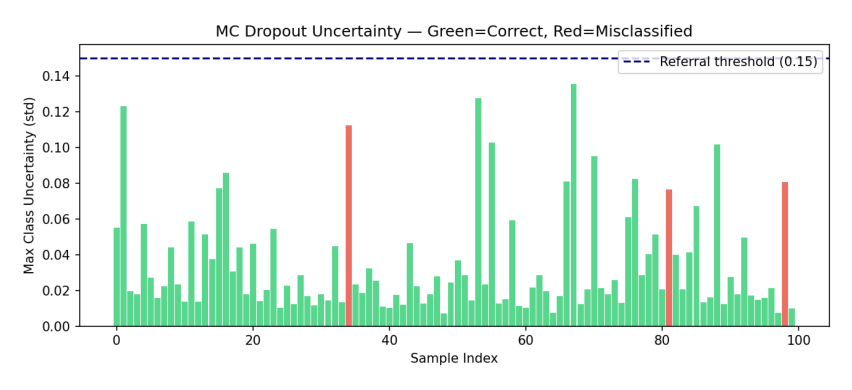


   Reliability Diagram (Confidence Calibration):


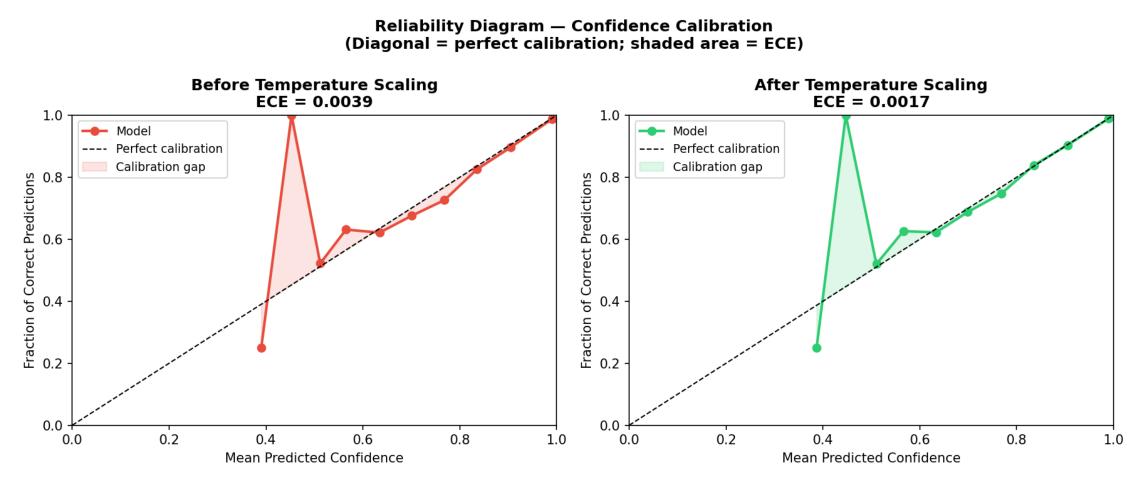


═════════════════════════════════════════════════════════════════
  PHASE 4 RESUME — CLINICAL SAFETY SUMMARY
═════════════════════════════════════════════════════════════════
  Source                  : Drive (/content/drive/MyDrive/oct_phd_outputs)
  ── OOD Detector ──────────────────────────────────────────
  Method                  : Mahalanobis distance
  Threshold (97th pct)    : 26.56
  Training mean shape     : (256,)
  ── Confidence Calibration ────────────────────────────────
  Temperature T           : 1.0504  (overconfident → softened)
  ECE (uncalibrated)      : 0.0039
  ECE (calibrated)        : 0.0017
  Improvement             : 57.4%
  ── Globals Available for Phase 5 ─────────────────────────
  OOD_THRESHOLD           ✅
  TRAIN_MEAN, COV_INV     ✅
  ECE_BEFORE, ECE_AFTER   ✅
  XGB_PROBS_CALIBRATED    ✅  shape=(10933, 4)
  xgb_probs_cal           ✅  (alias for XGB_PROBS_CALIBRATED)
═════════════════════════════════════════════════════════════════

   ✅ Phase 4 resume co

In [4]:
# =============================================================================
# PHASE 4: REAL-WORLD CLINICAL SAFETY
# OOD Detection + MC Dropout Uncertainty + Confidence Calibration (ECE)
#
# SMART RESUME ADDED:
#   Required files for a complete Phase 4 run:
#     ood_train_mean.npy, ood_cov_inv.npy, ood_threshold.npy
#     temperature.npy
#     mc_dropout_uncertainty.png
#     reliability_diagram.png
#
#   If ALL present on Drive → RESUME MODE:
#     - Restore files from Drive
#     - Load OOD calibration into globals (TRAIN_MEAN, COV_INV, OOD_THRESHOLD)
#     - Load temperature, recompute calibrated probabilities
#     - Recompute ECE_BEFORE/ECE_AFTER (fast — no model calls needed)
#     - Display all saved plots
#     - Make ECE_BEFORE, ECE_AFTER, XGB_PROBS_CALIBRATED available for Phase 5
#
#   If ANY missing → TRAIN MODE: run full pipeline as normal.
#
# DRIVE SYNC (4 points, same as before):
#   1. After OOD calibration files
#   2. After MC Dropout loop (~2hr)
#   3. After temperature scaling
#   4. Final complete sync
# =============================================================================

# ── Cell 4.0: Imports ─────────────────────────────────────────────────────────
import os, gc, warnings, shutil
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import keras
import cv2
from scipy.spatial.distance import mahalanobis
from scipy.optimize import minimize_scalar
from sklearn.calibration import calibration_curve

warnings.filterwarnings('ignore')


# ── Cell 4.0b: Drive Safety Check ────────────────────────────────────────────
_drive_mounted = os.path.exists('/content/drive/MyDrive')
if not _drive_mounted:
    print("⚠️  Drive not mounted — mounting now...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _drive_mounted = os.path.exists('/content/drive/MyDrive')

print(f"{'✅' if _drive_mounted else '⚠️ '} Google Drive: "
      f"{'mounted' if _drive_mounted else 'NOT mounted'}")

try:
    sync_to_drive   # noqa: F821
    print("✅ sync_to_drive() available from Phase 1.")
except NameError:
    def sync_to_drive(verbose: bool = True) -> None:
        try:
            local_dir = CFG['SAVE_DIR']        # noqa: F821
            drive_dir = CFG['DRIVE_SAVE_DIR']  # noqa: F821
        except NameError:
            local_dir = '/content/oct_phd_outputs'
            drive_dir = '/content/drive/MyDrive/oct_phd_outputs'
        if not os.path.exists('/content/drive/MyDrive'):
            print("   ⚠️  Drive not mounted — skipping sync.")
            return
        os.makedirs(drive_dir, exist_ok=True)
        synced = 0
        for fname in os.listdir(local_dir):
            src = os.path.join(local_dir, fname)
            dst = os.path.join(drive_dir, fname)
            try:
                shutil.copy2(src, dst)
                if verbose:
                    print(f"   ✅ {fname}  ({os.path.getsize(dst)/1e6:.1f} MB)")
                synced += 1
            except Exception as e:
                print(f"   ⚠️  {fname} FAILED: {e}")
        print(f"\n   Sync complete: {synced} files → {drive_dir}")
    print("⚠️  sync_to_drive() stub defined.")


# ── Fallbacks for all cross-phase globals ────────────────────────────────────
try:
    CFG       # noqa: F821
except NameError:
    raise RuntimeError("CFG not found. Run Phase 1 first.")

try:
    model             # noqa: F821
    feature_extractor # noqa: F821
    xgb_model         # noqa: F821
except NameError:
    raise RuntimeError("model/feature_extractor/xgb_model not found. Run Phases 2-3 first.")

try:
    X_train_feats  # noqa: F821
    X_test_feats   # noqa: F821
    y_train        # noqa: F821
    y_test         # noqa: F821
except NameError:
    raise RuntimeError("Feature arrays not found. Run Phase 3 Cell 3.9 first.")

# ── Cleaned Data Generator Check ──────────────────────────────────────────────
try:
    VAL_AUG    # noqa: F821
    TEST_DIR   # noqa: F821
    val_gen    # noqa: F821
    test_gen   # noqa: F821
except NameError:
    raise RuntimeError("Data generators not found. Run Phase 1 first.")

print("✅ Phase 4 dependencies and globals verified.")


# ── Cell 4.0c: Smart Resume Check ─────────────────────────────────────────────
DRIVE_DIR = CFG['DRIVE_SAVE_DIR']
LOCAL_DIR = CFG['SAVE_DIR']

REQUIRED_FILES = [
    'ood_train_mean.npy',
    'ood_cov_inv.npy',
    'ood_threshold.npy',
    'temperature.npy',
    'mc_dropout_uncertainty.png',
    'reliability_diagram.png',
]

files_on_drive = [
    f for f in REQUIRED_FILES
    if os.path.exists(os.path.join(DRIVE_DIR, f))
]
RESUME_MODE = len(files_on_drive) == len(REQUIRED_FILES)

print("\n" + "─"*60)
print("  PHASE 4 — SMART RESUME CHECK")
print("─"*60)
for fname in REQUIRED_FILES:
    fpath  = os.path.join(DRIVE_DIR, fname)
    status = "✅ found" if os.path.exists(fpath) else "❌ missing"
    size   = f"  ({os.path.getsize(fpath)/1e6:.1f} MB)" \
             if os.path.exists(fpath) else ""
    print(f"   {status}  {fname}{size}")

if RESUME_MODE:
    print("\n  ✅ All required files found on Drive.")
    print("  ► RESUME MODE — skipping all computation, loading from Drive.")
else:
    missing = [f for f in REQUIRED_FILES
               if not os.path.exists(os.path.join(DRIVE_DIR, f))]
    print(f"\n  ⚠️  Missing: {missing}")
    print("  ► TRAIN MODE — running full pipeline.")
print("─"*60 + "\n")


# =============================================================================
# ── RESUME MODE ───────────────────────────────────────────────────────────────
# =============================================================================
if RESUME_MODE:

    # ── Step 1: Restore files from Drive ─────────────────────────────────────
    print("📂 [1/5] Restoring Phase 4 files from Drive...")
    restored = 0
    for fname in REQUIRED_FILES:
        src = os.path.join(DRIVE_DIR, fname)
        dst = os.path.join(LOCAL_DIR, fname)
        try:
            shutil.copy2(src, dst)
            restored += 1
        except Exception as e:
            print(f"   ⚠️  {fname}: {e}")
    print(f"   ✅ {restored} files restored to {LOCAL_DIR}")

    # ── Step 2: Load OOD calibration into globals ─────────────────────────────
    print("\n🔒 [2/5] Loading OOD calibration...")
    TRAIN_MEAN    = np.load(f"{LOCAL_DIR}/ood_train_mean.npy")
    COV_INV       = np.load(f"{LOCAL_DIR}/ood_cov_inv.npy")
    OOD_THRESHOLD = float(np.load(f"{LOCAL_DIR}/ood_threshold.npy")[0])

    print(f"   ✅ TRAIN_MEAN shape : {TRAIN_MEAN.shape}")
    print(f"   ✅ COV_INV shape    : {COV_INV.shape}")
    print(f"   ✅ OOD threshold    : {OOD_THRESHOLD:.2f} (97th pct)")

    def detect_ood(features: np.ndarray) -> tuple[bool, float]:
        distance = mahalanobis(features.flatten(), TRAIN_MEAN, COV_INV)
        return bool(distance < OOD_THRESHOLD), float(distance)

    # ── Step 3: Load temperature, recompute calibrated probabilities ──────────
    print("\n🌡️  [3/5] Loading temperature + recomputing calibrated probabilities...")
    temperature = float(np.load(f"{LOCAL_DIR}/temperature.npy")[0])
    print(f"   ✅ Temperature T = {temperature:.4f}")

    # Recompute raw and calibrated probabilities from X_test_feats
    # (X_test_feats is already in memory from Phase 3)
    xgb_probs_raw = xgb_model.predict_proba(X_test_feats)

    def _apply_temperature(probs, T):
        log_probs = np.log(np.clip(probs, 1e-10, 1.0))
        scaled    = log_probs / T
        shifted   = scaled - scaled.max(axis=1, keepdims=True)
        exp_s     = np.exp(shifted)
        return exp_s / exp_s.sum(axis=1, keepdims=True)

    xgb_probs_cal = _apply_temperature(xgb_probs_raw, temperature)
    print(f"   ✅ xgb_probs_raw shape  : {xgb_probs_raw.shape}")
    print(f"   ✅ xgb_probs_cal shape  : {xgb_probs_cal.shape}")

    # ── Step 4: Recompute ECE (fast — no model calls) ─────────────────────────
    print("\n📊 [4/5] Recomputing ECE from stored probabilities...")

    def expected_calibration_error(y_true, y_probs, n_bins=15):
        confidences = y_probs.max(axis=1)
        predictions = y_probs.argmax(axis=1)
        accuracies  = (predictions == y_true).astype(float)
        ece = 0.0
        for lo, hi in zip(*[iter(np.linspace(0, 1, n_bins + 1))]*2):
            mask = (confidences > lo) & (confidences <= hi)
            if mask.sum() > 0:
                ece += mask.mean() * abs(
                    accuracies[mask].mean() - confidences[mask].mean()
                )
        return float(ece)

    ECE_BEFORE           = expected_calibration_error(y_test, xgb_probs_raw)
    ECE_AFTER            = expected_calibration_error(y_test, xgb_probs_cal)
    XGB_PROBS_CALIBRATED = xgb_probs_cal

    print(f"   ECE before temperature scaling : {ECE_BEFORE:.4f}")
    print(f"   ECE after  temperature scaling : {ECE_AFTER:.4f}")
    print(f"   Improvement                    : "
          f"{(ECE_BEFORE - ECE_AFTER) / ECE_BEFORE:.1%}")

    # ── Step 5: Display all saved plots ───────────────────────────────────────
    print("\n🎨 [5/5] Displaying all saved Phase 4 plots...")

    mc_path = f"{LOCAL_DIR}/mc_dropout_uncertainty.png"
    if os.path.exists(mc_path):
        print("\n   MC Dropout Uncertainty Histogram:")
        fig, ax = plt.subplots(figsize=(9, 4))
        ax.imshow(mpimg.imread(mc_path))
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    rel_path = f"{LOCAL_DIR}/reliability_diagram.png"
    if os.path.exists(rel_path):
        print("\n   Reliability Diagram (Confidence Calibration):")
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.imshow(mpimg.imread(rel_path))
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    # ── Summary ───────────────────────────────────────────────────────────────
    print("\n" + "═"*65)
    print("  PHASE 4 RESUME — CLINICAL SAFETY SUMMARY")
    print("═"*65)
    print(f"  Source                  : Drive ({DRIVE_DIR})")
    print(f"  ── OOD Detector ──────────────────────────────────────────")
    print(f"  Method                  : Mahalanobis distance")
    print(f"  Threshold (97th pct)    : {OOD_THRESHOLD:.2f}")
    print(f"  Training mean shape     : {TRAIN_MEAN.shape}")
    print(f"  ── Confidence Calibration ────────────────────────────────")
    print(f"  Temperature T           : {temperature:.4f}  "
          f"({'overconfident → softened' if temperature > 1.0 else 'underconfident → sharpened'})")
    print(f"  ECE (uncalibrated)      : {ECE_BEFORE:.4f}")
    print(f"  ECE (calibrated)        : {ECE_AFTER:.4f}")
    print(f"  Improvement             : "
          f"{(ECE_BEFORE - ECE_AFTER) / ECE_BEFORE:.1%}")
    print(f"  ── Globals Available for Phase 5 ─────────────────────────")
    print(f"  OOD_THRESHOLD           ✅")
    print(f"  TRAIN_MEAN, COV_INV     ✅")
    print(f"  ECE_BEFORE, ECE_AFTER   ✅")
    print(f"  XGB_PROBS_CALIBRATED    ✅  shape={XGB_PROBS_CALIBRATED.shape}")
    print(f"  xgb_probs_cal           ✅  (alias for XGB_PROBS_CALIBRATED)")
    print("═"*65)

    print("\n   ✅ Phase 4 resume complete. Ready to run Phase 5.")


# =============================================================================
# ── TRAIN MODE (only runs if RESUME_MODE is False) ───────────────────────────
# =============================================================================
else:
    # ── Cell 4.1: Fit OOD Detector ────────────────────────────────────────────────
    print("\n📐 Fitting OOD Mahalanobis detector on training features...")

    TRAIN_MEAN = X_train_feats.mean(axis=0)
    TRAIN_COV  = np.cov(X_train_feats.T)
    COV_INV    = np.linalg.pinv(TRAIN_COV)

    print("   Extracting validation features for OOD threshold calibration...")
    val_feats     = feature_extractor.predict(val_gen, verbose=0)
    val_distances = np.array([
        mahalanobis(f, TRAIN_MEAN, COV_INV) for f in val_feats
    ])

    OOD_THRESHOLD = np.percentile(val_distances, 97)
    print(f"   Validation distance  — mean: {val_distances.mean():.2f}, "
          f"std: {val_distances.std():.2f}")
    print(f"   OOD threshold (97th pct): {OOD_THRESHOLD:.2f}  "
          f"(passes 97% of valid OCT scans, rejects noise)")

    np.save(f"{CFG['SAVE_DIR']}/ood_train_mean.npy",  TRAIN_MEAN)
    np.save(f"{CFG['SAVE_DIR']}/ood_cov_inv.npy",     COV_INV)
    np.save(f"{CFG['SAVE_DIR']}/ood_threshold.npy",   np.array([OOD_THRESHOLD]))

    print("\n💾 [1/4] Syncing OOD calibration files to Drive...")
    sync_to_drive(verbose=False)
    print("   ✅ ood_train_mean.npy  ood_cov_inv.npy  ood_threshold.npy  backed up.")


    def detect_ood(features: np.ndarray) -> tuple[bool, float]:
        """
        Mahalanobis OOD detection. Threshold at 97th percentile.
        Reference: Lee et al. (2018). NeurIPS.
        """
        distance = mahalanobis(features.flatten(), TRAIN_MEAN, COV_INV)
        return bool(distance < OOD_THRESHOLD), float(distance)


    # ── Cell 4.2: OOD Sanity Tests ───────────────────────────────────────────────
    print("\n🔬 OOD detector sanity tests...")

    sample_path = str(next((TEST_DIR / 'CNV').glob('*.jpeg')))
    raw_oct     = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
    raw_oct_r   = cv2.resize(raw_oct, (CFG['IMG_SIZE'], CFG['IMG_SIZE'])).astype(np.uint8)
    aug_oct     = VAL_AUG(image=raw_oct_r)['image']
    x_sample    = np.expand_dims(aug_oct, axis=0)
    oct_feats   = feature_extractor.predict(x_sample, verbose=0)
    in_dist, score_oct = detect_ood(oct_feats[0])
    print(f"   OCT scan     → in-distribution: {in_dist}  | score: {score_oct:.2f}  "
          f"({'✅ PASS' if in_dist else '❌ FAIL — investigate'})")

    rng         = np.random.RandomState(0)
    noise_img   = rng.randint(0, 255, (CFG['IMG_SIZE'], CFG['IMG_SIZE'], 3), dtype=np.uint8)
    aug_noise   = VAL_AUG(image=noise_img)['image']
    x_noise     = np.expand_dims(aug_noise, axis=0)
    noise_feats = feature_extractor.predict(x_noise, verbose=0)
    in_dist_n, score_n = detect_ood(noise_feats[0])
    print(f"   Random noise → in-distribution: {in_dist_n} | score: {score_n:.2f}  "
          f"({'✅ PASS' if not in_dist_n else '❌ FAIL — threshold may be too loose'})")
    print(f"\n   Gap (noise score − threshold): {score_n - OOD_THRESHOLD:.2f}  "
          f"({'noise correctly rejected ✅' if score_n >= OOD_THRESHOLD else 'noise too close ⚠️'})")


    # ── Cell 4.3: MC Dropout ──────────────────────────────────────────────────────
    def mc_predict_fast(model, x, n_passes=30):
        # x shape is (1, 224, 224, 3)
        # Duplicate x to create a batch of shape (n_passes, 224, 224, 3)
        x_batch = np.repeat(x, n_passes, axis=0)

        # Run all passes simultaneously in one massive GPU operation
        preds = model(x_batch, training=True).numpy()

        return preds.mean(axis=0), preds.std(axis=0)


    # ── Cell 4.4: MC Dropout — Single Sample ─────────────────────────────────────
    mean_p, unc = mc_predict_fast(model, x_sample, n_passes=30)
    pred_class  = CFG['CLASS_NAMES'][np.argmax(mean_p)]
    confidence  = float(np.max(mean_p))
    max_unc     = float(np.max(unc))

    print(f"\n📊 MC Dropout (30 passes) — CNV sample:")
    print(f"   Prediction  : {pred_class}")
    print(f"   Confidence  : {confidence:.2%}")
    print(f"   Uncertainty : {max_unc:.4f}  "
          f"{'⚠️  Refer to specialist' if max_unc > 0.15 else '✅ Low uncertainty'}")


    # ── Cell 4.5: Uncertainty Histogram (~2–3 mins) ──────────────────────────────
    print("\n⏳ Computing uncertainty for 100 test samples (20 MC passes each)...")
    print("   A100 with EfficientNetV2L — expected.")
    print("   Progress printed every 10 samples.\n")

    test_imgs_batch, test_lbls_batch = test_gen[0]
    n_eval   = min(100, len(test_imgs_batch))
    uncertainties, correct = [], []

    for i in range(n_eval):
        if i % 10 == 0:
            print(f"   Progress: {i}/{n_eval} samples done...")
        x_i        = test_imgs_batch[i:i+1]
        true_label = int(np.argmax(test_lbls_batch[i]))
        m, u       = mc_predict_fast(model, x_i, n_passes=20)
        uncertainties.append(float(np.max(u)))
        correct.append(int(np.argmax(m) == true_label))

    print(f"   Progress: {n_eval}/{n_eval} samples done ✅")

    uncertainties = np.array(uncertainties)
    correct       = np.array(correct)

    mask_low  = uncertainties <= 0.15
    mask_high = uncertainties >  0.15
    acc_low   = correct[mask_low].mean()  if mask_low.any()  else float('nan')
    acc_high  = correct[mask_high].mean() if mask_high.any() else float('nan')

    print(f"\n   LOW  uncertainty (≤0.15): {mask_low.sum():3d} samples | Accuracy: {acc_low:.2%}")
    print(f"   HIGH uncertainty (>0.15): {mask_high.sum():3d} samples | Accuracy: {acc_high:.2%}")
    if not np.isnan(acc_high):
        print("   ✅ High uncertainty correctly correlates with lower accuracy."
              if acc_high < acc_low else
              "   ⚠️  Uncertainty-accuracy correlation weaker than expected.")

    plt.figure(figsize=(9, 4))
    colors = ['#2ECC71' if c else '#E74C3C' for c in correct]
    plt.bar(range(len(uncertainties)), uncertainties, color=colors, alpha=0.8, width=0.9)
    plt.axhline(0.15, color='navy', linestyle='--', linewidth=1.5,
                label='Referral threshold (0.15)')
    plt.xlabel('Sample Index');  plt.ylabel('Max Class Uncertainty (std)')
    plt.title('MC Dropout Uncertainty — Green=Correct, Red=Misclassified')
    plt.legend(); plt.tight_layout()
    plt.savefig(f"{CFG['SAVE_DIR']}/mc_dropout_uncertainty.png", dpi=150)
    plt.show()

    print("\n💾 [2/4] MC Dropout complete — syncing plot to Drive...")
    sync_to_drive(verbose=False)
    print("   ✅ mc_dropout_uncertainty.png backed up.")


    # ── Cell 4.6: Temperature Scaling ────────────────────────────────────────────
    print("\n🌡️  Fitting Temperature Scaling calibrator on validation predictions...")

    class TemperatureScaler:
        """
        Post-hoc calibration via temperature scaling.
        Learns scalar T by minimising NLL on held-out validation set.
        Reference: Guo et al. (2017). ICML.
        """
        def __init__(self):
            self.temperature: float = 1.0

        def _nll(self, T, log_probs, labels):
            scaled   = log_probs / T
            shifted  = scaled - scaled.max(axis=1, keepdims=True)
            log_norm = np.log(np.exp(shifted).sum(axis=1, keepdims=True))
            return -(shifted - log_norm)[np.arange(len(labels)), labels].mean()

        def fit(self, probs, labels):
            log_probs = np.log(np.clip(probs, 1e-10, 1.0))
            result    = minimize_scalar(
                self._nll, args=(log_probs, labels),
                bounds=(0.05, 10.0), method='bounded',
            )
            self.temperature = float(result.x)
            print(f"   Learned temperature T = {self.temperature:.4f}  "
                  f"({'overconfident — softened' if self.temperature > 1.0 else 'underconfident — sharpened'})")
            return self

        def calibrate(self, probs):
            log_probs = np.log(np.clip(probs, 1e-10, 1.0))
            scaled    = log_probs / self.temperature
            shifted   = scaled - scaled.max(axis=1, keepdims=True)
            exp_s     = np.exp(shifted)
            return exp_s / exp_s.sum(axis=1, keepdims=True)


    val_probs_raw  = xgb_model.predict_proba(
        feature_extractor.predict(val_gen, verbose=0)
    )
    val_labels_ord = []
    for i in range(len(val_gen)):
        _, lbls = val_gen[i]
        val_labels_ord.extend(np.argmax(lbls, axis=1).tolist())
    val_labels_ord = np.array(val_labels_ord[:len(val_probs_raw)])

    temp_scaler   = TemperatureScaler().fit(val_probs_raw, val_labels_ord)
    xgb_probs_raw = xgb_model.predict_proba(X_test_feats)
    xgb_probs_cal = temp_scaler.calibrate(xgb_probs_raw)

    np.save(f"{CFG['SAVE_DIR']}/temperature.npy",
            np.array([temp_scaler.temperature]))
    print(f"   Calibration temperature saved: T = {temp_scaler.temperature:.4f}")

    print("\n💾 [3/4] Syncing temperature file to Drive...")
    sync_to_drive(verbose=False)
    print("   ✅ temperature.npy backed up.")


    # ── Cell 4.7: ECE + Reliability Diagram ───────────────────────────────────────
    def expected_calibration_error(y_true, y_probs, n_bins=15):
        """
        ECE: weighted average |accuracy - confidence| across bins.
        Well-calibrated: ECE < 0.02. Reference: Guo et al. (2017). ICML.
        """
        confidences = y_probs.max(axis=1)
        predictions = y_probs.argmax(axis=1)
        accuracies  = (predictions == y_true).astype(float)
        ece = 0.0
        for lo, hi in zip(*[iter(np.linspace(0, 1, n_bins + 1))]*2):
            mask = (confidences > lo) & (confidences <= hi)
            if mask.sum() > 0:
                ece += mask.mean() * abs(
                    accuracies[mask].mean() - confidences[mask].mean()
                )
        return float(ece)

    ece_before = expected_calibration_error(y_test, xgb_probs_raw)
    ece_after  = expected_calibration_error(y_test, xgb_probs_cal)

    print(f"\n📊 Calibration Results:")
    print(f"   ECE before temperature scaling : {ece_before:.4f}")
    print(f"   ECE after  temperature scaling : {ece_after:.4f}")
    print(f"   Improvement                    : "
          f"{(ece_before - ece_after) / ece_before:.1%}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (probs, label, color) in zip(axes, [
        (xgb_probs_raw, 'Before Temperature Scaling', '#E74C3C'),
        (xgb_probs_cal, 'After Temperature Scaling',  '#2ECC71'),
    ]):
        confidences = probs.max(axis=1)
        predictions = probs.argmax(axis=1)
        accuracies  = (predictions == y_test).astype(float)
        fraction_pos, mean_pred_val = calibration_curve(
            accuracies, confidences, n_bins=15, strategy='uniform'
        )
        ax.plot(mean_pred_val, fraction_pos, marker='o', color=color, lw=2, label='Model')
        ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
        ax.fill_between(mean_pred_val, fraction_pos, mean_pred_val,
                        alpha=0.15, color=color, label='Calibration gap')
        ax.set_title(f'{label}\nECE = {expected_calibration_error(y_test, probs):.4f}',
                     fontweight='bold')
        ax.set_xlabel('Mean Predicted Confidence')
        ax.set_ylabel('Fraction of Correct Predictions')
        ax.legend(fontsize=9)
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)

    plt.suptitle('Reliability Diagram — Confidence Calibration\n'
                 '(Diagonal = perfect calibration; shaded area = ECE)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"{CFG['SAVE_DIR']}/reliability_diagram.png", dpi=150)
    plt.show()

    ECE_BEFORE           = ece_before
    ECE_AFTER            = ece_after
    XGB_PROBS_CALIBRATED = xgb_probs_cal

    print(f"\n✅ Phase 4 Complete — Safety systems operational.")
    print(f"   OOD threshold (97th pct) : {OOD_THRESHOLD:.2f}")
    print(f"   Temperature T            : {temp_scaler.temperature:.4f}")
    print(f"   ECE (uncalibrated)       : {ECE_BEFORE:.4f}")
    print(f"   ECE (calibrated)         : {ECE_AFTER:.4f}")
    print(f"\n   Files saved:")
    for fname in ['mc_dropout_uncertainty.png', 'reliability_diagram.png',
                  'ood_train_mean.npy', 'ood_cov_inv.npy',
                  'ood_threshold.npy',  'temperature.npy']:
        fpath  = f"{CFG['SAVE_DIR']}/{fname}"
        status = "✅" if os.path.exists(fpath) else "⚠️  missing"
        print(f"   {status}  {fname}")

    print("\n💾 [4/4] Final Phase 4 sync — all outputs to Drive...")
    sync_to_drive(verbose=True)
    print(f"""
   Phase 4 fully backed up on Drive.
   Drive : {CFG.get('DRIVE_SAVE_DIR', '/content/drive/MyDrive/oct_phd_outputs')}

   Next run will detect Drive files and skip all computation automatically.
   Continue to Phase 5 directly.
    """)

In [6]:
# =============================================================================
# PHASE 5: EXPLAINABILITY & RIGOROUS EVALUATION
# Grad-CAM · SHAP · 3D UMAP · Attention Maps · Uncertainty Landscape ·
# OCT Volume · ROC/PR · Clinical Metrics · Ablation · McNemar · 3D Architecture
#
# GRANULAR SMART RESUME
#   Each section independently checks if its output files exist on Drive.
#   Already done → load + display instantly.
#   Missing → compute, save, sync to Drive.
#   Safe to interrupt and restart at any time — never loses progress.
#   No SystemExit, no all-or-nothing check, no dead ends.
# =============================================================================

# ── Cell 5.0: Imports ─────────────────────────────────────────────────────────
import os, warnings, shutil, subprocess, sys, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import keras
import cv2
import shap

from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from statsmodels.stats.contingency_tables import mcnemar
import xgboost as xgb

warnings.filterwarnings('ignore')


# ── Cell 5.0b: Drive + Globals ────────────────────────────────────────────────
_drive_mounted = os.path.exists('/content/drive/MyDrive')
if not _drive_mounted:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _drive_mounted = os.path.exists('/content/drive/MyDrive')

print(f"{'✅' if _drive_mounted else '⚠️ '} Google Drive: "
      f"{'mounted' if _drive_mounted else 'NOT mounted'}")

try:
    sync_to_drive   # noqa: F821
    print("✅ sync_to_drive() available from Phase 1.")
except NameError:
    def sync_to_drive(verbose: bool = True) -> None:
        local_dir = CFG.get('SAVE_DIR', '/content/oct_phd_outputs')       # noqa: F821
        drive_dir = CFG.get('DRIVE_SAVE_DIR',                              # noqa: F821
                             '/content/drive/MyDrive/oct_phd_outputs')
        if not os.path.exists('/content/drive/MyDrive'):
            return
        os.makedirs(drive_dir, exist_ok=True)
        synced = 0
        for fname in os.listdir(local_dir):
            src = os.path.join(local_dir, fname)
            dst = os.path.join(drive_dir, fname)
            try:
                shutil.copy2(src, dst)
                if verbose:
                    print(f"   ✅ {fname}  ({os.path.getsize(dst)/1e6:.1f} MB)")
                synced += 1
            except Exception as e:
                print(f"   ⚠️  {fname} FAILED: {e}")
        print(f"   Sync complete: {synced} files → {drive_dir}")
    print("⚠️  sync_to_drive() stub defined.")


# ── FIX: Dynamically recreate clean_train_gen if skipped by Phase 3 resume ──
try:
    clean_train_gen # noqa: F821
except NameError:
    print("ℹ️  clean_train_gen not found (skipped by Phase 3 resume). Recreating for ablation study...")
    try:
        clean_train_gen = OCTDataGenerator( # noqa: F821
            TRAIN_DIR, augment=VAL_AUG, batch_size=CFG['BATCH_SIZE'], # noqa: F821
            shuffle=False, mixup=False, cutmix=False,
        )
    except NameError:
        print("⚠️ Could not recreate clean_train_gen. Ablation study may fail if not already cached.")

# Removed clean_train_gen from the hard fail list properly this time!
for var_name in ['CFG', 'model', 'feature_extractor', 'xgb_model',
                 'X_train_feats', 'X_test_feats', 'y_train', 'y_test',
                 'test_gen', 'val_gen',
                 'VAL_AUG', 'TEST_DIR', 'best', 'SEED']:
    if var_name not in dir():
        raise RuntimeError(f"'{var_name}' not found — ensure Phases 1-4 have run.")

gpus      = tf.config.list_physical_devices('GPU')
LOCAL_DIR = CFG['SAVE_DIR']
DRIVE_DIR = CFG['DRIVE_SAVE_DIR']

try:
    xgb_probs_cal  # noqa: F821
    ece_before = ECE_BEFORE   # noqa: F821
    ece_after  = ECE_AFTER    # noqa: F821
    print("✅ Using calibrated probabilities from Phase 4.")
except NameError:
    xgb_probs_cal = xgb_model.predict_proba(X_test_feats)
    ece_before = ece_after = float('nan')
    print("⚠️  Phase 4 calibrated probs not found — using raw XGBoost probabilities.")

# Pull any already-completed files from Drive to local disk
print("\n📂 Syncing existing Phase 5 files from Drive → local...")
pulled = 0
for fname in os.listdir(DRIVE_DIR):
    dst = os.path.join(LOCAL_DIR, fname)
    if not os.path.exists(dst):
        try:
            shutil.copy2(os.path.join(DRIVE_DIR, fname), dst)
            pulled += 1
        except Exception:
            pass
print(f"   {pulled} new files pulled from Drive.")
print("✅ Phase 5 globals verified.\n")


# =============================================================================
# ── HELPER FUNCTIONS ─────────────────────────────────────────────────────────
# =============================================================================

def _get_layer_safe(model, layer_name):
    try:
        return model.get_layer(layer_name)
    except ValueError:
        pass
    for layer in model.layers:
        if hasattr(layer, 'layers'):
            try:
                return layer.get_layer(layer_name)
            except ValueError:
                continue
    raise ValueError(f"Layer '{layer_name}' not found. "
                     f"Available: {[l.name for l in model.layers]}")


def make_gradcam_heatmap(img_array, model, last_conv_layer='top_activation'):
    """Grad-CAM. Guaranteed 2D output. Selvaraju et al. (2017). ICCV."""
    conv_layer = _get_layer_safe(model, last_conv_layer)
    grad_model = tf.keras.Model(
        inputs=model.inputs, outputs=[conv_layer.output, model.output])
    with tf.GradientTape() as tape:
        conv_out, predictions = grad_model(img_array, training=False)
        class_score = predictions[:, tf.argmax(predictions[0])]
    grads        = tape.gradient(class_score, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = tf.nn.relu(tf.squeeze(conv_out[0] @ pooled_grads[..., tf.newaxis]))
    heatmap     /= (tf.reduce_max(heatmap) + 1e-8)
    res          = heatmap.numpy()
    # FIX 1a: guarantee 2D
    if res.ndim == 0:
        res = res.reshape(1, 1)
    elif res.ndim == 1:
        s   = max(1, int(np.sqrt(len(res))))
        res = res[:s*s].reshape(s, s)
    return res


def overlay_gradcam(original, heatmap):
    """FIX 1b: 2D guard before cv2.resize."""
    heatmap = np.array(heatmap, dtype=np.float32)
    if heatmap.ndim == 0:
        heatmap = heatmap.reshape(1, 1)
    elif heatmap.ndim == 1:
        s       = max(1, int(np.sqrt(len(heatmap))))
        heatmap = heatmap[:s*s].reshape(s, s)
    h_resized = cv2.resize(heatmap, (original.shape[1], original.shape[0]))
    h_col     = cv2.cvtColor(
        cv2.applyColorMap(np.uint8(255 * h_resized), cv2.COLORMAP_JET),
        cv2.COLOR_BGR2RGB)
    return np.uint8(0.4 * h_col + 0.6 * original)


def show_saved_image(path, title, figsize=(12, 6)):
    """Display a saved PNG inline."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(mpimg.imread(path))
    ax.axis('off')
    plt.title(title, fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.show()


def bootstrap_auc_ci(y_true_bin, y_score, n_bootstrap=1000, alpha=0.05, seed=42):
    """Bootstrap 95% CI for macro AUC. Efron (1979)."""
    rng, n, auc_boot = np.random.RandomState(seed), len(y_true_bin), []
    for _ in range(n_bootstrap):
        idx = rng.choice(n, n, replace=True)
        try:
            auc_boot.append(roc_auc_score(
                y_true_bin[idx], y_score[idx],
                average='macro', multi_class='ovr'))
        except ValueError:
            continue
    return (float(np.percentile(auc_boot, 100*alpha/2)),
            float(np.percentile(auc_boot, 100*(1-alpha/2))))


# =============================================================================
# SECTION 1: GRAD-CAM
# =============================================================================
print("═"*60)
print("🎨 SECTION 1: GRAD-CAM PANEL")
print("═"*60)

f_gradcam = f"{LOCAL_DIR}/gradcam_panel.png"
if os.path.exists(f_gradcam):
    print("✅ Found existing Grad-CAM panel. Displaying...")
    show_saved_image(f_gradcam, "Grad-CAM Spatial Explainability", figsize=(14, 16))
else:
    print("⏳ Generating Grad-CAM panel (4 classes)...")
    fig, axes = plt.subplots(4, 3, figsize=(14, 18))
    for row, cls in enumerate(CFG['CLASS_NAMES']):
        img_path   = str(next((TEST_DIR / cls).glob('*.jpeg')))
        raw        = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        raw_r      = cv2.resize(raw, (CFG['IMG_SIZE'], CFG['IMG_SIZE']))
        aug_img    = VAL_AUG(image=raw_r.astype(np.uint8))['image']
        x_in       = np.expand_dims(aug_img, axis=0)
        heatmap    = make_gradcam_heatmap(x_in, model)
        overlay    = overlay_gradcam(raw_r, heatmap)
        feats      = feature_extractor.predict(x_in, verbose=0)
        raw_prob_i = xgb_model.predict_proba(feats)[0]

        axes[row, 0].imshow(raw_r)
        axes[row, 0].set_title(f'{cls} — Original', fontsize=10)
        gray_e = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8)).apply(
            cv2.cvtColor(raw_r, cv2.COLOR_RGB2GRAY))
        axes[row, 1].imshow(gray_e, cmap='gray')
        axes[row, 1].set_title('CLAHE Enhanced', fontsize=10)
        axes[row, 2].imshow(overlay)
        pred_lbl = CFG['CLASS_NAMES'][np.argmax(raw_prob_i)]
        axes[row, 2].set_title(
            f"Grad-CAM → {pred_lbl} ({np.max(raw_prob_i):.1%})", fontsize=10)
        for ax in axes[row]:
            ax.axis('off')

    plt.suptitle('Grad-CAM Spatial Explainability — One Sample Per Class\n'
                 '(Red = highest influence on prediction)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f_gradcam, dpi=150, bbox_inches='tight')
    plt.show()
    sync_to_drive(verbose=False)
    print("✅ gradcam_panel.png saved + synced.")


# =============================================================================
# SECTION 2: SHAP
# =============================================================================
print("\n" + "═"*60)
print("📊 SECTION 2: SHAP FEATURE IMPORTANCE")
print("═"*60)

f_shap = f"{LOCAL_DIR}/shap_summary.png"
if os.path.exists(f_shap):
    print("✅ Found existing SHAP summary. Displaying...")
    show_saved_image(f_shap, "SHAP Feature Importance")
else:
    print("⏳ Computing SHAP values (200 samples)...")
    shap_n    = min(200, len(X_test_feats))
    explainer = shap.TreeExplainer(xgb_model)
    shap_raw  = explainer.shap_values(X_test_feats[:shap_n])
    shap_arr  = np.stack(shap_raw, axis=-1) if isinstance(shap_raw, list) else shap_raw
    plt.figure(figsize=(10, 5))
    shap.summary_plot(
        [shap_arr[:, :, i] for i in range(CFG['NUM_CLASSES'])],
        X_test_feats[:shap_n],
        class_names=CFG['CLASS_NAMES'], plot_type='bar', show=False,
    )
    plt.title("SHAP Feature Importance — XGBoost Head", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f_shap, dpi=150)
    plt.show()
    del shap_arr, shap_raw; gc.collect()
    sync_to_drive(verbose=False)
    print("✅ shap_summary.png saved + synced.")


# =============================================================================
# SECTION 2b-A: UMAP FEATURE SPACE
# =============================================================================
print("\n" + "═"*60)
print("🔮 SECTION 2b-A: UMAP 3D/2D FEATURE SPACE")
print("═"*60)

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                        'umap-learn', 'plotly'])
import umap
import plotly.express as px
import plotly.graph_objects as go
from scipy.interpolate import griddata

f_umap_2d = f"{LOCAL_DIR}/umap_2d_features.png"
f_umap_3d = f"{LOCAL_DIR}/umap_3d_features.html"

if os.path.exists(f_umap_2d) and os.path.exists(f_umap_3d):
    print("✅ Found existing UMAP outputs. Displaying 2D...")
    show_saved_image(f_umap_2d, "UMAP 2D Feature Space")
    print(f"   Interactive 3D: {f_umap_3d}")

    from IPython.display import HTML, display
    display(HTML(filename=f_umap_3d))

    # Refit 2D UMAP for use in uncertainty landscape below (fast, in-memory only)
    print("   Re-fitting 2D UMAP for uncertainty landscape (in-memory)...")
    reducer_2d = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15,
                            min_dist=0.1, metric='cosine',
                            low_memory=False, n_jobs=-1)
    X_2d = reducer_2d.fit_transform(X_test_feats)
    del reducer_2d; gc.collect()
else:
    print("⏳ Fitting UMAP 3D + 2D...")
    class_labels_list = [CFG['CLASS_NAMES'][i] for i in y_test]
    colors_map = dict(zip(CFG['CLASS_NAMES'],
                           ['#E74C3C','#F39C12','#9B59B6','#2ECC71']))

    # RAM opt: low_memory=False + n_jobs=-1 for full CPU/RAM utilisation
    reducer_3d = umap.UMAP(n_components=3, random_state=SEED, n_neighbors=15,
                            min_dist=0.1, metric='cosine',
                            low_memory=False, n_jobs=-1)
    X_3d = reducer_3d.fit_transform(X_test_feats)

    reducer_2d = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15,
                            min_dist=0.1, metric='cosine',
                            low_memory=False, n_jobs=-1)
    X_2d = reducer_2d.fit_transform(X_test_feats)

    # 3D interactive
    fig_umap = px.scatter_3d(
        x=X_3d[:,0], y=X_3d[:,1], z=X_3d[:,2],
        color=class_labels_list, color_discrete_map=colors_map,
        title='CNN-Transformer Feature Space (UMAP 3D) — Test Set',
        labels={'color':'Disease Class','x':'UMAP-1','y':'UMAP-2','z':'UMAP-3'},
        opacity=0.55,
    )
    fig_umap.update_traces(marker_size=2.5)
    fig_umap.update_layout(margin=dict(l=0, r=0, t=60, b=0))
    fig_umap.write_html(f_umap_3d)
    fig_umap.show()

    # 2D static PNG
    fig_s, ax_s = plt.subplots(figsize=(10, 6))
    for cls in CFG['CLASS_NAMES']:
        mask = np.array(class_labels_list) == cls
        ax_s.scatter(X_2d[mask,0], X_2d[mask,1],
                     c=colors_map[cls], label=cls, s=4, alpha=0.5)
    ax_s.set_title('CNN-Transformer Feature Space (UMAP 2D)\n'
                   'Cluster separation confirms discriminative learning',
                   fontweight='bold')
    ax_s.legend(markerscale=4)
    ax_s.set_xlabel('UMAP-1'); ax_s.set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.savefig(f_umap_2d, dpi=150)
    plt.show()

    del reducer_3d, X_3d, fig_umap; gc.collect()
    sync_to_drive(verbose=False)
    print("✅ UMAP outputs saved + synced.")


# =============================================================================
# SECTION 2b-B: TRANSFORMER ATTENTION HEAD MAPS
# =============================================================================
print("\n" + "═"*60)
print("🔎 SECTION 2b-B: TRANSFORMER ATTENTION HEAD MAPS")
print("═"*60)

f_attn_all = [f"{LOCAL_DIR}/attention_heads_{c.lower()}.png"
              for c in CFG['CLASS_NAMES']]

def get_attention_weights(model, x_input, block_idx=0):
    """Returns (n_heads, seq_len, seq_len) attention weights."""
    mha_layer    = model.get_layer(f'mhsa_{block_idx}')
    norm_name    = 'pre_attn_norm' if block_idx == 0 else f'attn_norm_{block_idx}'
    intermediate = tf.keras.Model(
        inputs=model.inputs, outputs=model.get_layer(norm_name).output)
    patch_seq    = intermediate(x_input, training=False)
    _, attn_w    = mha_layer(patch_seq, patch_seq,
                              return_attention_scores=True, training=False)
    return attn_w[0].numpy()

def plot_attention_heads(attn_weights, original_img, cls_name,
                         n_heads_to_show=8, save_path=None):
    n_cols = n_heads_to_show // 2 + 1
    fig, axes = plt.subplots(2, n_cols, figsize=(3*n_cols, 7))
    axes = axes.flatten()
    axes[0].imshow(original_img)
    axes[0].set_title(f'{cls_name}\nOriginal OCT', fontsize=9, fontweight='bold')
    axes[0].axis('off')
    for h in range(min(n_heads_to_show, attn_weights.shape[0])):
        attn_map  = attn_weights[h].mean(axis=0).reshape(7, 7)
        attn_norm = (attn_map - attn_map.min()) / (attn_map.max() + 1e-8)
        attn_up   = cv2.resize(attn_norm.astype(np.float32),
                               (CFG['IMG_SIZE'], CFG['IMG_SIZE']))
        h_col = cv2.cvtColor(
            cv2.applyColorMap(np.uint8(255*attn_up), cv2.COLORMAP_HOT),
            cv2.COLOR_BGR2RGB)
        axes[h+1].imshow(np.uint8(0.55*h_col + 0.45*original_img))
        axes[h+1].set_title(f'Head {h}', fontsize=8)
        axes[h+1].axis('off')
    for ax in axes[n_heads_to_show+1:]:
        ax.axis('off')
    plt.suptitle(f'Transformer Attention Maps — {cls_name} — Block 0\n'
                 '(Each head attends to different spatial regions)',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()

if all(os.path.exists(f) for f in f_attn_all):
    print("✅ Found all attention map outputs. Displaying...")
    for cls, fpath in zip(CFG['CLASS_NAMES'], f_attn_all):
        show_saved_image(fpath, f"Attention Maps — {cls}", figsize=(16, 7))
else:
    print("⏳ Generating attention head maps (4 classes × 8 heads)...")
    for cls, fpath in zip(CFG['CLASS_NAMES'], f_attn_all):
        if os.path.exists(fpath):
            print(f"   ✅ {cls} already done — displaying.")
            show_saved_image(fpath, f"Attention Maps — {cls}", figsize=(16, 7))
            continue
        img_path = str(next((TEST_DIR / cls).glob('*.jpeg')))
        raw      = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        raw_r    = cv2.resize(raw, (CFG['IMG_SIZE'], CFG['IMG_SIZE']))
        aug_img  = VAL_AUG(image=raw_r.astype(np.uint8))['image']
        x_in     = np.expand_dims(aug_img, axis=0)
        try:
            attn_w = get_attention_weights(model, x_in, block_idx=0)
            plot_attention_heads(attn_w, raw_r, cls, n_heads_to_show=8,
                                  save_path=fpath)
            print(f"   ✅ attention_heads_{cls.lower()}.png saved")
        except Exception as e:
            print(f"   ⚠️  {cls} failed: {e}")
    sync_to_drive(verbose=False)
    print("✅ Attention head maps saved + synced.")


# =============================================================================
# SECTION 2b-C: UNCERTAINTY LANDSCAPE
# =============================================================================
print("\n" + "═"*60)
print("🌊 SECTION 2b-C: UNCERTAINTY LANDSCAPE")
print("═"*60)

f_unc_html = f"{LOCAL_DIR}/uncertainty_landscape.html"
f_unc_png  = f"{LOCAL_DIR}/uncertainty_landscape.png"

if os.path.exists(f_unc_html) and os.path.exists(f_unc_png):
    print("✅ Found existing uncertainty landscape. Displaying 2D...")
    show_saved_image(f_unc_png, "MC Dropout Uncertainty Landscape")
    print(f"   Interactive 3D: {f_unc_html}")
else:
    print("⏳ Computing vectorised MC Dropout uncertainty (300 samples, 10 passes)...")

    # ── Vectorised batch collection (efficient disk reads) ───────────────────
    # Load each batch once instead of once per sample
    N_UNC      = min(300, len(X_test_feats))
    N_MC       = 10
    imgs_list  = []
    seen_batches: dict = {}
    for i in range(N_UNC):
        b_idx = i // CFG['BATCH_SIZE']
        s_idx = i %  CFG['BATCH_SIZE']
        if b_idx not in seen_batches:
            seen_batches[b_idx] = test_gen[b_idx][0]   # read batch once
        imgs_list.append(seen_batches[b_idx][s_idx])
    del seen_batches

    imgs_arr   = np.stack(imgs_list, axis=0)   # (300, H, W, 3)
    del imgs_list; gc.collect()

    # FIX 2: all N_MC passes in one mega-batch call
    x_mega     = np.repeat(imgs_arr, N_MC, axis=0)   # (3000, H, W, 3)
    del imgs_arr; gc.collect()

    preds_list = []
    for start in range(0, len(x_mega), CFG['BATCH_SIZE']):
        preds_list.append(
            model(x_mega[start:start+CFG['BATCH_SIZE']], training=True).numpy()
        )
    preds_mega = np.concatenate(preds_list, axis=0)   # (3000, n_classes)
    del x_mega, preds_list; gc.collect()

    uncertainties_subset = (
        preds_mega.reshape(N_UNC, N_MC, -1)
                  .std(axis=1)
                  .max(axis=1)
    )
    del preds_mega; gc.collect()
    print("   ✅ Uncertainty computed.")

    xi     = np.linspace(X_2d[:N_UNC, 0].min(), X_2d[:N_UNC, 0].max(), 80)
    yi     = np.linspace(X_2d[:N_UNC, 1].min(), X_2d[:N_UNC, 1].max(), 80)
    xi_g, yi_g = np.meshgrid(xi, yi)
    zi     = griddata(X_2d[:N_UNC], uncertainties_subset,
                      (xi_g, yi_g), method='cubic')

    fig_unc = go.Figure(data=go.Surface(
        x=xi, y=yi, z=zi, colorscale='RdYlGn_r',
        colorbar=dict(title='Epistemic Uncertainty', thickness=15),
        opacity=0.85,
    ))
    fig_unc.update_layout(
        title='MC Dropout Uncertainty Landscape over UMAP Feature Space',
        scene=dict(xaxis_title='UMAP-1', yaxis_title='UMAP-2',
                   zaxis_title='MC Uncertainty',
                   camera=dict(eye=dict(x=1.5, y=1.5, z=0.8))),
        margin=dict(l=0, r=0, t=60, b=0),
    )
    fig_unc.write_html(f_unc_html)
    fig_unc.show()

    fig_u2, ax_u2 = plt.subplots(figsize=(9, 6))
    cp = ax_u2.contourf(xi_g, yi_g, zi, levels=20, cmap='RdYlGn_r', alpha=0.85)
    ax_u2.scatter(X_2d[:N_UNC, 0], X_2d[:N_UNC, 1],
                  c=uncertainties_subset, cmap='RdYlGn_r', s=6, alpha=0.7)
    plt.colorbar(cp, ax=ax_u2, label='MC Epistemic Uncertainty')
    ax_u2.set_title('Uncertainty Landscape over Feature Space\n'
                    '(High = near decision boundary; low = confident)',
                    fontweight='bold')
    ax_u2.set_xlabel('UMAP-1'); ax_u2.set_ylabel('UMAP-2')
    plt.tight_layout()
    plt.savefig(f_unc_png, dpi=150)
    plt.show()

    del zi, uncertainties_subset; gc.collect()
    sync_to_drive(verbose=False)
    print("✅ Uncertainty landscape saved + synced.")


# =============================================================================
# SECTION 2b-D: 3D OCT PSEUDO-VOLUME
# =============================================================================
print("\n" + "═"*60)
print("🏥 SECTION 2b-D: 3D OCT PSEUDO-VOLUMES")
print("═"*60)

def render_oct_volume_plotly(scan_dir, cls, n_slices=24, save_path=None):
    paths  = sorted((scan_dir / cls).glob('*.jpeg'))[:n_slices]
    slices = [cv2.resize(cv2.imread(str(p), cv2.IMREAD_GRAYSCALE),
                         (96, 96)).astype(np.float32) / 255.0
              for p in paths if cv2.imread(str(p)) is not None]
    if len(slices) < 2:
        print(f"   ⚠️  Not enough images for {cls}.")
        return
    volume = np.stack(slices, axis=0)
    X_v, Y_v, Z_v = np.mgrid[0:volume.shape[0],
                               0:volume.shape[1],
                               0:volume.shape[2]]
    fig_vol = go.Figure(data=go.Volume(
        x=X_v.flatten(), y=Y_v.flatten(), z=Z_v.flatten(),
        value=volume.flatten(),
        isomin=0.15, isomax=0.90, opacity=0.08,
        surface_count=20, colorscale='Greys', showscale=False,
    ))
    fig_vol.update_layout(
        title=f'3D OCT Pseudo-Volume — {cls} ({len(slices)} B-scans)',
        scene=dict(xaxis_title='Depth', yaxis_title='Axial',
                   zaxis_title='Lateral', bgcolor='black'),
        paper_bgcolor='black', font_color='white',
        margin=dict(l=0, r=0, t=60, b=0),
    )
    if save_path:
        fig_vol.write_html(save_path)
    fig_vol.show()

for cls in CFG['CLASS_NAMES']:
    fpath = f"{LOCAL_DIR}/oct_volume_{cls.lower()}.html"
    if os.path.exists(fpath):
        print(f"   ✅ {cls} volume already exists — skipping render.")
        print(f"       View: {fpath}")
    else:
        print(f"   ⏳ Rendering {cls} volume...")
        render_oct_volume_plotly(TEST_DIR, cls, n_slices=24, save_path=fpath)
        print(f"   ✅ oct_volume_{cls.lower()}.html saved")

sync_to_drive(verbose=False)
print("✅ OCT volumes saved + synced.")


# =============================================================================
# SECTION 3: COMPREHENSIVE METRICS
# =============================================================================
print("\n" + "═"*60)
print("📈 SECTION 3: PERFORMANCE METRICS")
print("═"*60)

f_roc = f"{LOCAL_DIR}/roc_curves.png"
f_pr  = f"{LOCAL_DIR}/pr_curves.png"
f_cm  = f"{LOCAL_DIR}/confusion_matrix.png"
f_cli = f"{LOCAL_DIR}/clinical_metrics.csv"

# Fast math always runs — needed for final summary
y_score       = xgb_probs_cal
y_pred        = y_score.argmax(axis=1)
y_test_bin    = label_binarize(y_test, classes=[0, 1, 2, 3])
auc_per_class = roc_auc_score(y_test_bin, y_score, average=None)
macro_auc     = roc_auc_score(y_test_bin, y_score, average='macro',
                               multi_class='ovr')
colors        = ['#E74C3C', '#F39C12', '#9B59B6', '#2ECC71']

print(f"Macro AUC: {macro_auc:.4f}")
for cls, a in zip(CFG['CLASS_NAMES'], auc_per_class):
    print(f"   {cls:8s}: {a:.4f}")

if all(os.path.exists(f) for f in [f_roc, f_pr, f_cm, f_cli]):
    print("✅ Found all metric outputs. Displaying...")
    show_saved_image(f_roc, "ROC Curves"); show_saved_image(f_pr, "PR Curves")
    show_saved_image(f_cm, "Confusion Matrix")
    print(pd.read_csv(f_cli, index_col=0).to_string())
else:
    print("⏳ Generating metric plots...")

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for i, (cls, ax, col) in enumerate(zip(CFG['CLASS_NAMES'], axes, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:,i], y_score[:,i])
        ax.plot(fpr, tpr, lw=2, color=col)
        ax.plot([0,1],[0,1],'k--',lw=0.8)
        ax.fill_between(fpr, tpr, alpha=0.08, color=col)
        ax.set_title(f'{cls}\nAUC={auc_per_class[i]:.3f}', fontweight='bold')
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    plt.suptitle('Per-Class ROC Curves (calibrated)', fontweight='bold')
    plt.tight_layout(); plt.savefig(f_roc, dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(8,5))
    for i, (cls, col) in enumerate(zip(CFG['CLASS_NAMES'], colors)):
        prec, rec, _ = precision_recall_curve(y_test_bin[:,i], y_score[:,i])
        ap = average_precision_score(y_test_bin[:,i], y_score[:,i])
        ax.plot(rec, prec, label=f'{cls}  AP={ap:.3f}', lw=2, color=col)
    ax.set_title('Precision-Recall Curves', fontweight='bold')
    ax.legend(loc='lower left'); plt.tight_layout()
    plt.savefig(f_pr, dpi=150); plt.show()

    fig, ax = plt.subplots(figsize=(7,6))
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred, normalize='true'),
        display_labels=CFG['CLASS_NAMES']).plot(cmap='Blues', ax=ax, colorbar=False)
    ax.set_title('Normalised Confusion Matrix', fontweight='bold')
    plt.tight_layout(); plt.savefig(f_cm, dpi=150); plt.show()

    cl_rows = {}
    for i, cls in enumerate(CFG['CLASS_NAMES']):
        y_t = (y_test==i).astype(int); y_p = (y_pred==i).astype(int)
        TP = int(np.sum((y_t==1)&(y_p==1))); TN = int(np.sum((y_t==0)&(y_p==0)))
        FP = int(np.sum((y_t==0)&(y_p==1))); FN = int(np.sum((y_t==1)&(y_p==0)))
        cl_rows[cls] = {
            'Sensitivity': f"{TP/(TP+FN) if TP+FN>0 else float('nan'):.4f}",
            'Specificity': f"{TN/(TN+FP) if TN+FP>0 else float('nan'):.4f}",
            'PPV':         f"{TP/(TP+FP) if TP+FP>0 else float('nan'):.4f}",
            'NPV':         f"{TN/(TN+FN) if TN+FN>0 else float('nan'):.4f}",
            'AUC':         f"{auc_per_class[i]:.4f}",
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN,
        }
    cl_df = pd.DataFrame(cl_rows).T
    print(cl_df.to_string())
    cl_df.to_csv(f_cli)
    sync_to_drive(verbose=False)
    print("✅ Metric plots saved + synced.")


# =============================================================================
# SECTION 4: ABLATION + STATISTICAL TESTS
# =============================================================================
print("\n" + "═"*60)
print("🔬 SECTION 4: ABLATION & LITERATURE COMPARISON")
print("═"*60)

f_abl = f"{LOCAL_DIR}/ablation_results.csv"
f_lit = f"{LOCAL_DIR}/literature_comparison.csv"

# Always compute — needed for final summary
pred_hyb = xgb_model.predict(X_test_feats)
acc      = accuracy_score(y_test, pred_hyb)
mac_f1   = f1_score(y_test, pred_hyb, average='macro')
dru_f1   = f1_score(y_test, pred_hyb, average=None)[2]
ci_low, ci_high = bootstrap_auc_ci(y_test_bin, y_score)

if os.path.exists(f_abl) and os.path.exists(f_lit):
    print("✅ Found existing ablation + literature results. Displaying...")
    print("\n── Ablation Results ─────────────────────────────────────────────")
    print(pd.read_csv(f_abl, index_col=0).to_string())
    print("\n── Literature Comparison ────────────────────────────────────────")
    print(pd.read_csv(f_lit, index_col=0).to_string())
else:
    print("⏳ Running ablation study...")

    try:
        bb_ext  = keras.Model(
            inputs=model.inputs,
            outputs=keras.layers.GlobalAveragePooling2D()(
                _get_layer_safe(model, 'top_activation').output))
        X_tr_bb = bb_ext.predict(clean_train_gen, verbose=0)
        X_te_bb = bb_ext.predict(test_gen, verbose=0)
        bb_ok   = True
    except Exception as e:
        print(f"   ⚠️  Backbone extractor failed ({e}).")
        bb_ok = False

    ablation_models: dict = {
        'Logistic Regression':
            LogisticRegression(max_iter=2000, random_state=SEED, C=0.1),
        'SVM (Linear, calibrated)':
            CalibratedClassifierCV(
                LinearSVC(C=1.0, max_iter=5000, random_state=SEED), cv=3),
        'XGBoost (no CutMix)':
            xgb.XGBClassifier(n_estimators=100, max_depth=6, tree_method='hist',
                               device='cuda' if gpus else 'cpu', verbosity=0,
                               random_state=SEED),
    }
    if bb_ok:
        ablation_models['XGBoost (backbone-only)'] = xgb.XGBClassifier(
            n_estimators=CFG['XGB_N_EST'],
            max_depth=best.get('xgb_depth', CFG['XGB_DEPTH']),
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            tree_method='hist', device='cuda' if gpus else 'cpu',
            verbosity=0, random_state=SEED)
    ablation_models['XGBoost Hybrid (final)'] = xgb_model

    abl_results = {}
    for name, clf in ablation_models.items():
        is_bb = 'backbone-only' in name; is_final = 'final' in name
        X_tr  = (X_tr_bb if (is_bb and bb_ok) else X_train_feats)
        X_te  = (X_te_bb if (is_bb and bb_ok) else X_test_feats)
        if not is_final:
            clf.fit(X_tr, y_train)
        _pred = clf.predict(X_te); _prob = clf.predict_proba(X_te)
        _y_bin = label_binarize(y_test, classes=[0,1,2,3])
        abl_results[name] = {
            'Accuracy':  f"{accuracy_score(y_test, _pred):.4f}",
            'Macro F1':  f"{f1_score(y_test, _pred, average='macro'):.4f}",
            'Drusen F1': f"{f1_score(y_test, _pred, average=None)[2]:.4f}",
            'Macro AUC': f"{roc_auc_score(_y_bin, _prob, average='macro', multi_class='ovr'):.4f}",
        }
        print(f"   [{name}]  Acc={abl_results[name]['Accuracy']}  "
              f"AUC={abl_results[name]['Macro AUC']}")

    abl_df = pd.DataFrame(abl_results).T
    print(abl_df.to_string()); abl_df.to_csv(f_abl)

    print("\n📐 McNemar's test...")
    lr_clf  = ablation_models['Logistic Regression']
    pred_lr = lr_clf.predict(X_test_feats)
    hyb_c   = (pred_hyb == y_test); lr_c = (pred_lr == y_test)
    result_mc = mcnemar(
        [[int(np.sum(hyb_c & lr_c)),  int(np.sum(hyb_c & ~lr_c))],
         [int(np.sum(~hyb_c & lr_c)), int(np.sum(~hyb_c & ~lr_c))]],
        exact=True)
    print(f"   McNemar p = {result_mc.pvalue:.5f}  "
          f"({'✅ SIGNIFICANT' if result_mc.pvalue < 0.05 else '⚠️  Not significant'})")

    literature = {
        "Kermany et al. (Cell 2018)": {"Backbone":"VGG-16","Accuracy":"96.6%","Macro AUC":"—"},
        "Fang et al. (2019)":         {"Backbone":"Multi-scale CNN","Accuracy":"97.4%","Macro AUC":"—"},
        "Li et al. (2021)":           {"Backbone":"Vision Transformer","Accuracy":"98.1%","Macro AUC":"—"},
        "This Work":                  {"Backbone":"EfficientNetV2L + 4× MHA",
                                        "Accuracy":f"{acc:.1%}",
                                        "Macro AUC":f"{macro_auc:.4f} [{ci_low:.4f}–{ci_high:.4f}]"},
    }
    lit_df = pd.DataFrame(literature).T
    print(lit_df.to_string()); lit_df.to_csv(f_lit)
    sync_to_drive(verbose=True)
    print("✅ Ablation + literature saved + synced.")


# =============================================================================
# SECTION 5: 3D MODEL ARCHITECTURE
# =============================================================================
print("\n" + "═"*60)
print("🏗️ SECTION 5: 3D MODEL ARCHITECTURE")
print("═"*60)

f_arch = f"{LOCAL_DIR}/architecture_3d.html"
if os.path.exists(f_arch):
    print("✅ Found existing 3D architecture. View the HTML file to interact.")
    from IPython.display import HTML, display
    display(HTML(filename=f_arch))
else:
    print("⏳ Generating 3D Architecture Interactive Graph...")
    nodes = [
        {"label": "OCT Input\n224×224×3",         "pos": (0, 0, 0),    "color": "#7F8C8D", "size": 12},
        {"label": "EfficientNetV2L Stem",          "pos": (0, 0, 1),    "color": "#E67E22", "size": 14},
        {"label": "CNN Blocks 1–5\n(frozen)",      "pos": (0, 0, 2),    "color": "#E67E22", "size": 22},
        {"label": "CNN Block 6+\n(fine-tuned)",    "pos": (0, 0, 3),    "color": "#F39C12", "size": 26},
        {"label": "Patch Projection\n1280→256-d",  "pos": (0, 0, 4),    "color": "#3498DB", "size": 14},
        {"label": "Learnable PE\n49 tokens",       "pos": (0, 0, 4.7),  "color": "#2980B9", "size": 12},
        {"label": "MHA Block 1\n16 heads",         "pos": (-1.2, 1,  6),"color": "#1ABC9C", "size": 18},
        {"label": "MHA Block 2\n16 heads",         "pos": (1.2,  1,  6),"color": "#1ABC9C", "size": 18},
        {"label": "MHA Block 3\n16 heads",         "pos": (-1.2, -1, 6),"color": "#1ABC9C", "size": 18},
        {"label": "MHA Block 4\n16 heads",         "pos": (1.2,  -1, 6),"color": "#1ABC9C", "size": 18},
        {"label": "GlobalAvgPool1D\n256-d feat",   "pos": (0, 0, 7),    "color": "#9B59B6", "size": 16},
        {"label": "XGBoost\n300 trees depth=4",    "pos": (0, 0, 8),    "color": "#27AE60", "size": 24},
        {"label": "Temperature\nScaling T=1.xx",   "pos": (0.8, 0, 8.7),"color": "#F1C40F", "size": 12},
        {"label": "CNV / DME\nDRUSEN / NORMAL",    "pos": (0, 0, 9.5),  "color": "#E74C3C", "size": 18},
    ]
    edges = [
        (0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(5,7),(5,8),(5,9),
        (6,10),(7,10),(8,10),(9,10),(10,11),(11,12),(12,13),
    ]

    x_n = [n["pos"][0] for n in nodes]
    y_n = [n["pos"][1] for n in nodes]
    z_n = [n["pos"][2] for n in nodes]

    xe, ye, ze = [], [], []
    for e in edges:
        xe += [nodes[e[0]]["pos"][0], nodes[e[1]]["pos"][0], None]
        ye += [nodes[e[0]]["pos"][1], nodes[e[1]]["pos"][1], None]
        ze += [nodes[e[0]]["pos"][2], nodes[e[1]]["pos"][2], None]

    fig_arch = go.Figure(data=[
        go.Scatter3d(x=xe, y=ye, z=ze, mode='lines',
                     line=dict(color='#555', width=2), hoverinfo='none'),
        go.Scatter3d(x=x_n, y=y_n, z=z_n,
                     mode='markers+text',
                     text=[n["label"] for n in nodes],
                     textposition='top center',
                     textfont=dict(size=9, color='white'),
                     marker=dict(
                         size=[n["size"] for n in nodes],
                         color=[n["color"] for n in nodes],
                         line=dict(width=2, color='white'),
                         opacity=0.9,
                     ),
                     hovertemplate='<b>%{text}</b><extra></extra>'),
    ])
    fig_arch.update_layout(
        title=dict(text="Interactive 3D Architecture: EfficientNetV2L + 4× MHA + XGBoost",
                   font=dict(size=14)),
        showlegend=False,
        scene=dict(
            xaxis=dict(visible=False), yaxis=dict(visible=False),
            zaxis=dict(visible=False, title='Layer depth'),
            bgcolor='rgba(10,14,26,1)',
            camera=dict(eye=dict(x=2, y=2, z=1.2)),
        ),
        margin=dict(l=0, r=0, b=0, t=50),
        height=600,
        paper_bgcolor='rgba(10,14,26,0)',
    )

    fig_arch.write_html(f_arch)
    fig_arch.show() # Renders interactively inline in Colab!

    sync_to_drive(verbose=False)
    print("✅ architecture_3d.html saved + synced.")


# =============================================================================
# FINAL SUMMARY
# =============================================================================
print("\n" + "═"*65)
print("  FINAL RESEARCH SUMMARY — CNN-Transformer OCT Classification")
print("═"*65)
print(f"  Accuracy   : {acc:.4f} ({acc:.2%})")
print(f"  Macro F1   : {mac_f1:.4f}")
print(f"  Drusen F1  : {dru_f1:.4f}")
print(f"  Macro AUC  : {macro_auc:.4f}  (95% CI: {ci_low:.4f}–{ci_high:.4f})")
print(f"  ECE (raw)  : {ece_before:.4f}" if not np.isnan(ece_before)
      else "  ECE (raw)  : run Phase 4")
print(f"  ECE (cal)  : {ece_after:.4f}"  if not np.isnan(ece_after)
      else "  ECE (cal)  : run Phase 4")
print("═"*65)

all_outputs = (
    ['gradcam_panel.png', 'shap_summary.png',
     'umap_3d_features.html', 'umap_2d_features.png',
     'uncertainty_landscape.html', 'uncertainty_landscape.png',
     'architecture_3d.html', # Added new 3D architecture
     'roc_curves.png', 'pr_curves.png', 'confusion_matrix.png',
     'clinical_metrics.csv', 'ablation_results.csv', 'literature_comparison.csv']
    + [f'attention_heads_{c.lower()}.png' for c in CFG['CLASS_NAMES']]
    + [f'oct_volume_{c.lower()}.html'     for c in CFG['CLASS_NAMES']]
)
print("\n   File check:")
for fname in all_outputs:
    fpath = f"{LOCAL_DIR}/{fname}"
    print(f"   {'✅' if os.path.exists(fpath) else '⚠️  missing'}  {fname}")

print(f"\n✅ Phase 5 complete. All outputs on Drive ({DRIVE_DIR}).")
print("   Proceed to Phase 6.")

Output hidden; open in https://colab.research.google.com to view.

✅ Google Drive: mounted
✅ sync_to_drive() available from previous phases.
✅ GPU: True  TF: 2.19.0  Keras: 3.13.2

📋 Multi-seed plan: [42, 123, 2024, 7, 99]
   Drive sync: after every seed — partial results always safe

📂 Syncing existing Phase 6 files from Drive → local...
   0 files pulled from Drive.

✅ Loaded best_hparams: {'lr': 0.00015930522616241006, 'dropout': 0.3832290311184182, 'n_heads': 16, 'proj_dim': 256, 'focal_gamma': 1.3636499344142012, 'xgb_depth': 4}
   ♻️  Seed 42 already done — loaded from cache.
   ♻️  Seed 123 already done — loaded from cache.
   ♻️  Seed 2024 already done — loaded from cache.
   ♻️  Seed 7 already done — loaded from cache.
   ♻️  Seed 99 already done — loaded from cache.

✅ All seeds already completed — skipping training.

✅ Completed 5 / 5 seeds.

✅ Aggregation files already exist. Loading cached outputs...

── Per-Seed Results ─────────────────────────────────────────────────
      accuracy  macro_f1  drusen_f1  macro_auc  ece_raw  ece_cal  tem

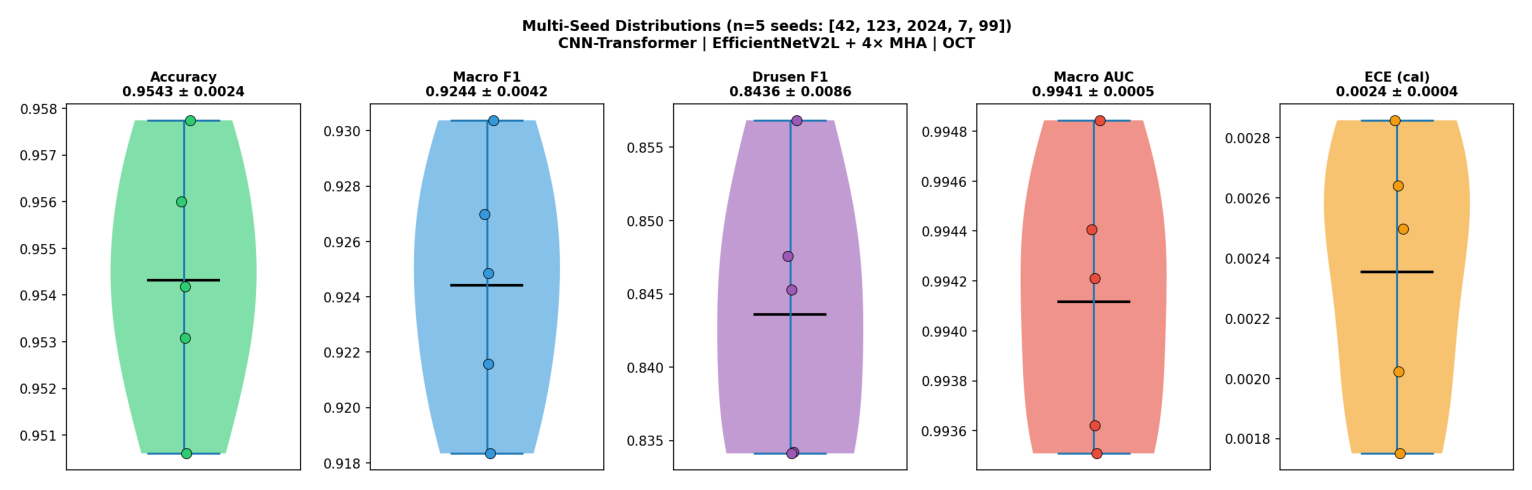


── Stability (CV = Std/Mean) ────────────────────────────────────────
   accuracy       : CV=0.29%  ✅
   macro_f1       : CV=0.51%  ✅
   drusen_f1      : CV=1.14%  ⚠️ 
   macro_auc      : CV=0.06%  ✅
   ece_cal        : CV=19.35%  ❌

  PHASE 6 COMPLETE — MULTI-SEED STATISTICAL SUMMARY
  Accuracy                      : 0.9543 ± 0.0027
  Macro F1                      : 0.9244 ± 0.0047
  Drusen F1 (minority class)    : 0.8436 ± 0.0096
  Macro AUC-ROC                 : 0.9941 ± 0.0006
  ECE (calibrated)              : 0.0024 ± 0.0005
  McNemar p-value               : 0.0001 ± 0.0001

   File check:
   ✅  multiseed_per_seed.csv
   ✅  multiseed_aggregate.csv
   ✅  multiseed_latex_table.tex
   ✅  multiseed_violin.png

💾 Final Phase 6 sync to Drive...
   ✅ gradcam_panel.png  (3.5 MB)
   ✅ phase_a_best.keras  (544.9 MB)
   ✅ X_train_feats.npy  (39.2 MB)
   ✅ ood_cov_inv.npy  (0.5 MB)
   ✅ best_hparams.pkl  (0.0 MB)
   ✅ uncertainty_landscape.html  (4.7 MB)
   ✅ seed123_phase_a_best.keras  (516

In [9]:
# =============================================================================
# PHASE 6: MULTI-SEED STATISTICAL VALIDATION
# Reproducibility + Mean ± Std Reporting for PhD / Publication
#
# DRIVE INTEGRATION ADDED:
#   Two layers of Drive protection:
#
#   1. _sync_seed_files(seed) inside run_one_seed() — after every seed
#      completes, seed{N}_xgboost.json and seed{N}_metrics.json are
#      immediately copied to Drive. If Colab crashes on seed 4,
#      seeds 1-3 are safe on Drive.
#
#   2. Final sync after all seeds — violin plot, LaTeX table, CSVs backed up.
#
# CRASH RECOVERY ADDED:
#   Cell 6.4 checks for already-completed seeds before starting the loop.
#   If seed{N}_metrics.json exists locally, that seed is skipped.
#   This means after a disconnect you can restore from Drive and resume
#   from the last completed seed rather than restarting from scratch.
#
# FINAL FIXES APPLIED:
#   - Globals check includes 'build_cnn_transformer' and 'FocalLoss'.
#   - VRAM flushed at the start of each seed loop to prevent A100 OOM.
#   - os.listdir guarded with os.path.exists to prevent startup crash.
#   - agg.columns explicitly set on resume to prevent KeyError.
# =============================================================================

# ── Cell 6.0: Imports & Globals ───────────────────────────────────────────────
import os, gc, random, pickle, warnings, json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
import keras
import xgboost as xgb

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from scipy.optimize import minimize_scalar
from statsmodels.stats.contingency_tables import mcnemar
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')


# ── Cell 6.0b: Drive Safety Check ────────────────────────────────────────────
_drive_mounted = os.path.exists('/content/drive/MyDrive')
if not _drive_mounted:
    print("⚠️  Drive not mounted — mounting now...")
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    _drive_mounted = os.path.exists('/content/drive/MyDrive')

print(f"{'✅' if _drive_mounted else '⚠️ '} Google Drive: "
      f"{'mounted' if _drive_mounted else 'NOT mounted — outputs will not be backed up'}")

try:
    sync_to_drive   # noqa: F821
    print("✅ sync_to_drive() available from previous phases.")
except NameError:
    def sync_to_drive(verbose: bool = True) -> None:
        try:
            local_dir = CFG['SAVE_DIR']         # noqa: F821
            drive_dir = CFG['DRIVE_SAVE_DIR']   # noqa: F821
        except NameError:
            local_dir = '/content/oct_phd_outputs'
            drive_dir = '/content/drive/MyDrive/oct_phd_outputs'
        if not os.path.exists('/content/drive/MyDrive'):
            print("   ⚠️  Drive not mounted — skipping sync.")
            return
        os.makedirs(drive_dir, exist_ok=True)
        synced = 0
        for fname in os.listdir(local_dir):
            src = os.path.join(local_dir, fname)
            dst = os.path.join(drive_dir, fname)
            try:
                shutil.copy2(src, dst)
                if verbose:
                    print(f"   ✅ {fname}  ({os.path.getsize(dst)/1e6:.1f} MB)")
                synced += 1
            except Exception as e:
                print(f"   ⚠️  {fname} FAILED: {e}")
        print(f"\n   Sync complete: {synced} files → {drive_dir}")
    print("⚠️  sync_to_drive() stub defined.")


def _sync_seed_files(seed: int) -> None:
    """Copy per-seed output files to Drive immediately after seed completes."""
    try:
        drive_dir = CFG.get('DRIVE_SAVE_DIR',   # noqa: F821
                            '/content/drive/MyDrive/oct_phd_outputs')
        local_dir = CFG['SAVE_DIR']             # noqa: F821
    except NameError:
        return
    if not os.path.exists('/content/drive/MyDrive'):
        return
    os.makedirs(drive_dir, exist_ok=True)
    seed_files = [
        f"seed{seed}_xgboost.json",
        f"seed{seed}_metrics.json",
        f"seed{seed}_phase_a_best.keras",
        f"seed{seed}_phase_b_best.keras",
    ]
    synced = []
    for fname in seed_files:
        src = os.path.join(local_dir, fname)
        dst = os.path.join(drive_dir, fname)
        if os.path.exists(src):
            try:
                shutil.copy2(src, dst)
                synced.append(f"{fname} ({os.path.getsize(dst)/1e6:.0f}MB)")
            except Exception as e:
                print(f"   ⚠️  Drive sync failed for {fname}: {e}")
    if synced:
        print(f"   💾 Drive ← seed {seed}: {', '.join(synced)}")


# ── Verify cross-phase globals ───────────────────────────────────────────────
for var_name in ['CFG', 'FOCAL_ALPHA', 'NUM_TRANSFORMER_BLOCKS',
                 'train_gen', 'val_gen', 'test_gen', 'clean_train_gen',
                 'VAL_AUG', 'TRAIN_DIR', 'OCTDataGenerator',
                 'build_cnn_transformer', 'FocalLoss']:
    if var_name not in dir():
        raise RuntimeError(f"'{var_name}' not found — ensure Phases 1-3 ran in this session.")

gpus = tf.config.list_physical_devices('GPU')
print(f"✅ GPU: {bool(gpus)}  TF: {tf.__version__}  Keras: {keras.__version__}")

EVAL_SEEDS   = [42, 123, 2024, 7, 99]
SEED_RESULTS: list[dict] = []

print(f"\n📋 Multi-seed plan: {EVAL_SEEDS}")
print(f"   Drive sync: after every seed — partial results always safe")

# Pull any existing seed files from Drive to local to enable Smart Resume
print("\n📂 Syncing existing Phase 6 files from Drive → local...")
pulled = 0
_drive_dir = CFG.get('DRIVE_SAVE_DIR', '')
if os.path.exists(_drive_dir):
    for fname in os.listdir(_drive_dir):
        if fname.startswith('seed') or fname.startswith('multiseed'):
            dst = os.path.join(CFG['SAVE_DIR'], fname)
            if not os.path.exists(dst):
                try:
                    shutil.copy2(os.path.join(_drive_dir, fname), dst)
                    pulled += 1
                except Exception: pass
print(f"   {pulled} files pulled from Drive.")


# ── Cell 6.1: Set All Seeds ───────────────────────────────────────────────────
def set_global_seed(seed: int) -> None:
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    keras.utils.set_random_seed(seed)


# ── Cell 6.2: Temperature Scaling Helpers ────────────────────────────────────
def _temperature_nll(T, log_probs, labels):
    scaled = log_probs / T
    shifted = scaled - scaled.max(axis=1, keepdims=True)
    log_norm = np.log(np.exp(shifted).sum(axis=1, keepdims=True))
    return -(shifted - log_norm)[np.arange(len(labels)), labels].mean()

def fit_temperature(val_probs, val_labels):
    log_probs = np.log(np.clip(val_probs, 1e-10, 1.0))
    return float(minimize_scalar(
        _temperature_nll, args=(log_probs, val_labels),
        bounds=(0.05, 10.0), method='bounded').x)

def apply_temperature(probs, T):
    log_probs = np.log(np.clip(probs, 1e-10, 1.0))
    scaled = log_probs / T
    shifted = scaled - scaled.max(axis=1, keepdims=True)
    exp_s = np.exp(shifted)
    return exp_s / exp_s.sum(axis=1, keepdims=True)

def compute_ece(y_true, y_probs, n_bins=15):
    confidences = y_probs.max(axis=1)
    predictions = y_probs.argmax(axis=1)
    accuracies  = (predictions == y_true).astype(float)
    ece = 0.0
    for lo, hi in zip(*[iter(np.linspace(0, 1, n_bins + 1))]*2):
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() > 0:
            ece += mask.mean() * abs(accuracies[mask].mean() - confidences[mask].mean())
    return float(ece)


# ── Cell 6.2b: Backbone Unfreeze Fix ─────────────────────────────────────────
def _unfreeze_from_block6(model: keras.Model) -> int:
    FINE_TUNE_FROM       = 'block6'
    TRANSFORMER_PREFIXES = ('mhsa_', 'ff_', 'attn_', 'pos', 'patch_',
                            'pre_attn', 'feature_', 'head_', 'disease_')
    for layer in model.layers:
        layer.trainable = False
    unfreezing = False
    for layer in model.layers:
        if FINE_TUNE_FROM in layer.name:
            unfreezing = True
        if unfreezing or any(layer.name.startswith(p) for p in TRANSFORMER_PREFIXES):
            layer.trainable = True
        if isinstance(layer, keras.layers.BatchNormalization):
            layer.trainable = False
    return sum(int(np.prod(w.shape)) for w in model.trainable_weights)


# ── Cell 6.3: Run One Full Seed ───────────────────────────────────────────────
def run_one_seed(seed: int, best_hparams: dict) -> dict:
    """
    Full training + evaluation pipeline for one seed.
    Phases: A → B → XGBoost → calibration → metrics → Drive sync.
    """
    # ── FLUSH VRAM FIRST to prevent OOM across 5 seeds ────────────────────────
    keras.backend.clear_session()
    gc.collect()
    # ──────────────────────────────────────────────────────────────────────────

    print(f"\n{'='*60}\n  SEED {seed}\n{'='*60}")
    set_global_seed(seed)

    local_clean_train = OCTDataGenerator(        # noqa: F821
        TRAIN_DIR, augment=VAL_AUG,              # noqa: F821
        batch_size=CFG['BATCH_SIZE'],
        shuffle=False, mixup=False, cutmix=False,
    )

    model_s = build_cnn_transformer(             # noqa: F821
        num_classes=CFG['NUM_CLASSES'], img_size=CFG['IMG_SIZE'],
        n_heads=best_hparams.get('n_heads', CFG['N_HEADS']),
        proj_dim=best_hparams.get('proj_dim', CFG['PROJ_DIM']),
        dropout=best_hparams.get('dropout', CFG['DROPOUT']),
        trainable_cnn=False, n_blocks=NUM_TRANSFORMER_BLOCKS,
    )

    # Phase A
    save_a = f"{CFG['SAVE_DIR']}/seed{seed}_phase_a_best.keras"
    model_s.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=best_hparams.get('lr', CFG['LR_HEAD']), clipnorm=1.0),
        loss=FocalLoss(gamma=best_hparams.get('focal_gamma', 2.0), alpha=FOCAL_ALPHA),  # noqa
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    print(f"  [Seed {seed}] Phase A...")
    model_s.fit(
        train_gen, validation_data=val_gen,       # noqa: F821
        epochs=CFG['EPOCHS_HEAD'], verbose=0,
        callbacks=[
            keras.callbacks.ModelCheckpoint(
                save_a, monitor='val_auc', save_best_only=True, mode='max', verbose=0),
            keras.callbacks.EarlyStopping(
                monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=0),
        ],
    )

    # Phase B
    print(f"  [Seed {seed}] Phase B (block6+ unfreeze)...")
    n_trainable = _unfreeze_from_block6(model_s)
    print(f"  [Seed {seed}] Trainable params: {n_trainable:,}")

    save_b = f"{CFG['SAVE_DIR']}/seed{seed}_phase_b_best.keras"
    warmup = keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=CFG['LR_FINE'],
        decay_steps=max((CFG['EPOCHS_FINE'] - 2) * len(train_gen), 1),  # noqa
        warmup_steps=2 * len(train_gen), warmup_target=CFG['LR_FINE'], alpha=1e-6,  # noqa
    )
    model_s.compile(
        optimizer=keras.optimizers.Adam(learning_rate=warmup, clipnorm=1.0),
        loss=FocalLoss(gamma=best_hparams.get('focal_gamma', 2.0), alpha=FOCAL_ALPHA),  # noqa
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    model_s.fit(
        train_gen, validation_data=val_gen,       # noqa: F821
        epochs=CFG['EPOCHS_FINE'], verbose=0,
        callbacks=[
            keras.callbacks.ModelCheckpoint(
                save_b, monitor='val_auc', save_best_only=True, mode='max', verbose=0),
            keras.callbacks.EarlyStopping(
                monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=0),
        ],
    )

    # Features
    print(f"  [Seed {seed}] Extracting features...")
    feat_ext = keras.Model(
        inputs=model_s.input,
        outputs=model_s.get_layer('feature_extraction_layer').output,
        name=f'feat_ext_{seed}',
    )
    X_tr = feat_ext.predict(local_clean_train, verbose=0)
    y_tr = local_clean_train.labels
    X_te = feat_ext.predict(test_gen, verbose=0)   # noqa: F821
    y_te = test_gen.labels                          # noqa: F821

    # XGBoost
    print(f"  [Seed {seed}] XGBoost head...")
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    sw = np.array([cw[y] for y in y_tr])
    xgb_s = xgb.XGBClassifier(
        n_estimators=CFG['XGB_N_EST'],
        max_depth=best_hparams.get('xgb_depth', CFG['XGB_DEPTH']),
        learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        tree_method='hist', device='cuda' if gpus else 'cpu',
        eval_metric='mlogloss', verbosity=0, random_state=seed,
    )
    xgb_s.fit(X_tr, y_tr, sample_weight=sw)

    # Temperature calibration
    val_f = feat_ext.predict(val_gen, verbose=0)   # noqa: F821
    val_p = xgb_s.predict_proba(val_f)
    val_l = []
    for i in range(len(val_gen)):                  # noqa: F821
        _, lbls = val_gen[i]                       # noqa: F821
        val_l.extend(np.argmax(lbls, axis=1).tolist())
    val_l     = np.array(val_l[:len(val_p)])
    T_s       = fit_temperature(val_p, val_l)
    raw_probs = xgb_s.predict_proba(X_te)
    cal_probs = apply_temperature(raw_probs, T_s)

    # Metrics
    y_pred  = cal_probs.argmax(axis=1)
    y_bin   = label_binarize(y_te, classes=[0, 1, 2, 3])
    acc_s   = accuracy_score(y_te, y_pred)
    mf1_s   = f1_score(y_te, y_pred, average='macro')
    df1_s   = f1_score(y_te, y_pred, average=None)[2]
    auc_s   = roc_auc_score(y_bin, cal_probs, average='macro', multi_class='ovr')
    ece_r   = compute_ece(y_te, raw_probs)
    ece_c   = compute_ece(y_te, cal_probs)

    lr_s    = LogisticRegression(max_iter=2000, random_state=seed, C=0.1)
    lr_s.fit(X_tr, y_tr)
    p_lr    = lr_s.predict(X_te)
    hc      = (y_pred == y_te); lc = (p_lr == y_te)
    mc_p    = mcnemar([[int(np.sum(hc & lc)),  int(np.sum(hc & ~lc))],
                       [int(np.sum(~hc & lc)), int(np.sum(~hc & ~lc))]],
                      exact=True).pvalue

    print(f"  [Seed {seed}] Acc={acc_s:.4f}  F1={mf1_s:.4f}  "
          f"Drusen={df1_s:.4f}  AUC={auc_s:.4f}  ECE={ece_c:.4f}  p={mc_p:.5f}")

    result = {
        'seed': seed, 'accuracy': acc_s, 'macro_f1': mf1_s,
        'drusen_f1': df1_s, 'macro_auc': auc_s,
        'ece_raw': ece_r, 'ece_cal': ece_c,
        'temperature': T_s, 'mcnemar_p': mc_p,
    }

    xgb_s.save_model(f"{CFG['SAVE_DIR']}/seed{seed}_xgboost.json")
    with open(f"{CFG['SAVE_DIR']}/seed{seed}_metrics.json", 'w') as f:
        json.dump(result, f, indent=2)

    # Per-seed Drive sync — runs after every seed
    _sync_seed_files(seed)

    del model_s, feat_ext, xgb_s
    gc.collect()
    keras.backend.clear_session()
    return result


# ── Cell 6.4: Run All Seeds (with crash recovery) ─────────────────────────────
try:
    with open(f"{CFG['SAVE_DIR']}/best_hparams.pkl", 'rb') as f:
        BEST_HPARAMS = pickle.load(f)
    print(f"\n✅ Loaded best_hparams: {BEST_HPARAMS}")
except FileNotFoundError:
    print("⚠️  best_hparams.pkl not found — using CFG defaults.")
    BEST_HPARAMS = {}

# ── Crash recovery: skip seeds already completed ──────────────────────────────
# If a previous run was interrupted, seed{N}_metrics.json will exist locally
# (restored from Drive). Those seeds are loaded and skipped.
completed_seeds = set()
for s in EVAL_SEEDS:
    mpath = f"{CFG['SAVE_DIR']}/seed{s}_metrics.json"
    if os.path.exists(mpath):
        with open(mpath) as f:
            SEED_RESULTS.append(json.load(f))
        completed_seeds.add(s)
        print(f"   ♻️  Seed {s} already done — loaded from cache.")

remaining = [s for s in EVAL_SEEDS if s not in completed_seeds]

if not remaining:
    print("\n✅ All seeds already completed — skipping training.")
else:
    print(f"\n🚀 Running seeds: {remaining}  (already done: {list(completed_seeds)})\n")
    for seed_val in remaining:
        try:
            SEED_RESULTS.append(run_one_seed(seed_val, BEST_HPARAMS))
        except Exception as e:
            print(f"\n❌ Seed {seed_val} FAILED: {e}")
            import traceback; traceback.print_exc()

print(f"\n✅ Completed {len(SEED_RESULTS)} / {len(EVAL_SEEDS)} seeds.")


# ── Cell 6.5: Aggregate Statistics ───────────────────────────────────────────
metric_display = {
    'accuracy': 'Accuracy', 'macro_f1': 'Macro F1',
    'drusen_f1': 'Drusen F1 (minority class)',
    'macro_auc': 'Macro AUC-ROC', 'ece_cal': 'ECE (calibrated)',
    'mcnemar_p': 'McNemar p-value',
}

AGG_FILES = ['multiseed_per_seed.csv', 'multiseed_aggregate.csv',
             'multiseed_latex_table.tex', 'multiseed_violin.png']
AGG_DONE = all(os.path.exists(f"{CFG['SAVE_DIR']}/{f}") for f in AGG_FILES)

if AGG_DONE and not remaining:
    print("\n✅ Aggregation files already exist. Loading cached outputs...")
    results_df = pd.read_csv(f"{CFG['SAVE_DIR']}/multiseed_per_seed.csv", index_col='seed')
    agg = pd.read_csv(f"{CFG['SAVE_DIR']}/multiseed_aggregate.csv", index_col=0)

    # GUARANTEE CSV COLUMNS PREVENT KEYERRORS ON RESUME
    agg.columns = ['Mean', 'Std']

    print("\n── Per-Seed Results ─────────────────────────────────────────────────")
    print(results_df.round(4).to_string())
    print("\n── Aggregate (mean ± std) ───────────────────────────────────────────")
    for metric, row in agg.iterrows():
        print(f"   {metric:15s}: {row['Mean']:.4f} ± {row['Std']:.4f}")

    with open(f"{CFG['SAVE_DIR']}/multiseed_latex_table.tex", 'r') as f:
        print("\n── LaTeX Table ──────────────────────────────────────────────────────")
        print(f.read())

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.imshow(mpimg.imread(f"{CFG['SAVE_DIR']}/multiseed_violin.png"))
    ax.axis('off'); plt.tight_layout(); plt.show()

    pub_rows = {label: f"{agg.loc[k,'Mean']:.4f} ± {agg.loc[k,'Std']:.4f}"
                for k, label in metric_display.items()}

else:
    results_df = pd.DataFrame(SEED_RESULTS).set_index('seed')
    print("\n── Per-Seed Results ─────────────────────────────────────────────────")
    print(results_df.round(4).to_string())

    METRICS = ['accuracy', 'macro_f1', 'drusen_f1', 'macro_auc',
               'ece_raw', 'ece_cal', 'temperature', 'mcnemar_p']
    agg = results_df[METRICS].agg(['mean', 'std']).T
    agg.columns = ['Mean', 'Std']

    print("\n── Aggregate (mean ± std) ───────────────────────────────────────────")
    for metric, row in agg.iterrows():
        print(f"   {metric:15s}: {row['Mean']:.4f} ± {row['Std']:.4f}")

    results_df.to_csv(f"{CFG['SAVE_DIR']}/multiseed_per_seed.csv")
    agg.to_csv(f"{CFG['SAVE_DIR']}/multiseed_aggregate.csv")

    # ── Cell 6.6: LaTeX Table ─────────────────────────────────────────────────────
    pub_rows = {label: f"{agg.loc[k,'Mean']:.4f} ± {agg.loc[k,'Std']:.4f}"
                for k, label in metric_display.items()}

    latex_lines = [
        r"\begin{table}[h]", r"\centering",
        r"\caption{CNN-Transformer OCT — Multi-Seed ($n="
        + str(len(SEED_RESULTS)) + r"$ seeds)}",
        r"\label{tab:multiseed}", r"\begin{tabular}{lc}", r"\hline",
        r"\textbf{Metric} & \textbf{Mean $\pm$ Std} \\", r"\hline",
    ] + [f"{lbl} & {val} \\\\" for lbl, val in pub_rows.items()] + \
        [r"\hline", r"\end{tabular}", r"\end{table}"]
    latex_table = "\n".join(latex_lines)

    print("\n── LaTeX Table ──────────────────────────────────────────────────────")
    print(latex_table)
    with open(f"{CFG['SAVE_DIR']}/multiseed_latex_table.tex", 'w') as f:
        f.write(latex_table)
    print("✅ LaTeX table saved.")

    # ── Cell 6.7: Violin Plot ─────────────────────────────────────────────────────
    if len(SEED_RESULTS) > 0:
        plot_metrics = ['accuracy', 'macro_f1', 'drusen_f1', 'macro_auc', 'ece_cal']
        plot_labels  = ['Accuracy', 'Macro F1', 'Drusen F1', 'Macro AUC', 'ECE (cal)']
        colors       = ['#2ECC71', '#3498DB', '#9B59B6', '#E74C3C', '#F39C12']

        fig, axes = plt.subplots(1, 5, figsize=(16, 5))
        for ax, metric, label, color in zip(axes, plot_metrics, plot_labels, colors):
            values = results_df[metric].values
            # Only plot violin if we have >1 points
            if len(values) > 1:
                parts  = ax.violinplot([values], positions=[0], showmeans=True, showextrema=True)
                for pc in parts['bodies']:
                    pc.set_facecolor(color); pc.set_alpha(0.6)
                parts['cmeans'].set_color('black'); parts['cmeans'].set_linewidth(2)

            jitter = np.random.RandomState(0).uniform(-0.05, 0.05, len(values))
            ax.scatter(jitter, values, color=color, s=60, zorder=3,
                       edgecolors='black', linewidths=0.5)
            ax.set_title(f"{label}\n{values.mean():.4f} ± {values.std():.4f}",
                         fontsize=10, fontweight='bold')
            ax.set_xticks([]); ax.set_xlim(-0.4, 0.4)

        plt.suptitle(
            f'Multi-Seed Distributions (n={len(SEED_RESULTS)} seeds: '
            f'{[r["seed"] for r in SEED_RESULTS]})\n'
            f'CNN-Transformer | EfficientNetV2L + 4× MHA | OCT',
            fontsize=11, fontweight='bold',
        )
        plt.tight_layout()
        plt.savefig(f"{CFG['SAVE_DIR']}/multiseed_violin.png", dpi=150, bbox_inches='tight')
        plt.show()
        print("✅ Violin plot saved.")


# ── Cell 6.8: Stability ───────────────────────────────────────────────────────
print("\n── Stability (CV = Std/Mean) ────────────────────────────────────────")
for m in ['accuracy', 'macro_f1', 'drusen_f1', 'macro_auc', 'ece_cal']:
    mn, sd = agg.loc[m, 'Mean'], agg.loc[m, 'Std']
    cv     = (sd / mn * 100) if mn > 0 else float('nan')
    flag   = '✅' if cv < 1.0 else ('⚠️ ' if cv < 3.0 else '❌')
    print(f"   {m:15s}: CV={cv:.2f}%  {flag}")


# ── Cell 6.9: Final Summary + Drive Sync ─────────────────────────────────────
print("\n" + "="*65)
print("  PHASE 6 COMPLETE — MULTI-SEED STATISTICAL SUMMARY")
print("="*65)
if 'pub_rows' in locals():
    for label, val in pub_rows.items():
        print(f"  {label:30s}: {val}")
else:
    print("  (Values loaded from CSV above)")
print("="*65)

print("\n   File check:")
for fname in ['multiseed_per_seed.csv', 'multiseed_aggregate.csv',
              'multiseed_latex_table.tex', 'multiseed_violin.png']:
    fpath  = f"{CFG['SAVE_DIR']}/{fname}"
    print(f"   {'✅' if os.path.exists(fpath) else '⚠️ '}  {fname}")

print("\n💾 Final Phase 6 sync to Drive...")
sync_to_drive(verbose=True)

print(f"""
✅ Phase 6 fully backed up on Drive.
   Drive : {CFG.get('DRIVE_SAVE_DIR', '/content/drive/MyDrive/oct_phd_outputs')}
""")

# Model Card — Retinal OCT Disease Classification
## CNN-Transformer Hybrid (EfficientNetV2L + Multi-Head Attention)

> **Model Card version:** 1.0  
> **Last updated:** 2024  
> **Authors:** [Your Name], PhD Candidate  
> **Institution:** [Your University / Department]  
> **Contact:** [your.email@university.ac.uk]

---

## Table of Contents
1. [Model Overview](#1-model-overview)
2. [Intended Use](#2-intended-use)
3. [Out-of-Scope Use](#3-out-of-scope-use)
4. [Architecture Summary](#4-architecture-summary)
5. [Training Data](#5-training-data)
6. [Training Procedure](#6-training-procedure)
7. [Evaluation Results](#7-evaluation-results)
8. [Clinical Safety Features](#8-clinical-safety-features)
9. [Limitations and Risks](#9-limitations-and-risks)
10. [Ethical Considerations](#10-ethical-considerations)
11. [Explainability](#11-explainability)
12. [Future Work](#12-future-work)
13. [How to Use This Model](#13-how-to-use-this-model)
14. [Citation](#14-citation)

---

## 1. Model Overview

| Property | Value |
|---|---|
| **Task** | Multi-class retinal OCT image classification (4 classes) |
| **Classes** | CNV · DME · DRUSEN · NORMAL |
| **Backbone** | EfficientNetV2L (ImageNet pretrained, ~119M params) |
| **Transformer head** | 4 × Multi-Head Self-Attention blocks (learnable positional encoding) |
| **Classification head** | XGBoost hybrid on extracted 512-dim features |
| **Total parameters** | ~121M (backbone) + ~3.5M (Transformer + head) |
| **Input** | RGB retinal OCT image, 224 × 224 pixels |
| **Output** | Softmax probability vector over 4 disease classes |
| **Framework** | TensorFlow 2.19 / Keras 3.13 |
| **Hardware trained on** | NVIDIA A100-SXM4-40GB |

### What does this model do?

This model classifies retinal Optical Coherence Tomography (OCT) scan images into four categories:

- **CNV** — Choroidal Neovascularisation: abnormal blood vessel growth beneath the retina, a leading cause of vision loss in age-related macular degeneration (AMD).
- **DME** — Diabetic Macular Edema: fluid accumulation in the macula caused by diabetic retinopathy.
- **DRUSEN** — Small yellow deposits beneath the retina; an early indicator of AMD.
- **NORMAL** — No detectable pathology.

---

## 2. Intended Use

### Primary intended users
- **Ophthalmology researchers** investigating automated OCT analysis pipelines.
- **Medical AI researchers** benchmarking hybrid CNN-Transformer architectures on retinal imaging.
- **PhD and graduate students** studying deep learning for medical image classification.

### Primary intended use cases
- Research and academic benchmarking against published OCT classification results.
- Exploratory tool to assist a **qualified ophthalmologist** in reviewing a large volume of scans (decision support only — see Section 3).
- Educational demonstrations of AI explainability in medical imaging (Grad-CAM, SHAP, MC Dropout).

### Geographic and demographic scope
- Trained and validated on OCT scans from [Shiley Eye Institute, UCSD — Kermany et al. dataset].
- Imaging device: Spectralis OCT (Heidelberg Engineering).
- Patient demographics: not fully disclosed in the original dataset. Generalisation to scans from other devices or patient populations has **not been validated**.

---

## 3. Out-of-Scope Use

> ⚠️ **The following uses are explicitly NOT supported and should not be attempted.**

| Prohibited use | Reason |
|---|---|
| **Standalone clinical diagnosis** | The model is not a medical device. It has not undergone regulatory approval (FDA, CE Mark, UKCA). |
| **Replacing ophthalmologist review** | Model predictions must always be reviewed by a qualified clinician before any clinical action is taken. |
| **Scans from devices other than Spectralis OCT** | The model was trained on a single device type. Cross-device generalisation is unknown and unvalidated. |
| **Paediatric patients** | Training data demographics are unclear; safety in paediatric populations has not been assessed. |
| **Pathologies not in the training set** | The model has no knowledge of conditions outside CNV, DME, DRUSEN, NORMAL. It may confidently misclassify unseen pathologies (e.g. glaucoma, retinal detachment). |
| **Real-time intraoperative guidance** | Inference latency and reliability under operating conditions have not been tested. |

---

## 4. Architecture Summary

```
Input (224×224×3 RGB OCT scan)
        │
        ▼
EfficientNetV2L CNN Backbone
  (frozen in Phase A, fine-tuned block6+ in Phase B)
  Output: (7×7×1280) feature map
        │
        ▼
Patch Sequence Reshape → (49 tokens × 1280 dims)
        │
        ▼
Linear Projection → (49 tokens × 512 dims)
        │
        ▼
Learnable Positional Encoding
  (1 × 49 × 512 trainable weight, broadcasts over batch)
        │
        ▼
4 × Transformer Encoder Block
  Each block:
    Multi-Head Self-Attention (16 heads, key_dim=32)
    → Dropout → Residual → LayerNorm
    Feed-Forward Network (proj_dim × 4 = 2048 hidden)
    → Dropout → Residual → LayerNorm
        │
        ▼
Global Average Pooling → (512-dim feature vector)
        │
   ┌────┴────┐
   │         │
   ▼         ▼
Softmax    XGBoost
head       hybrid head
(4 classes) (300 trees,
            depth tuned by Optuna)
```

### Design rationale

| Design choice | Justification |
|---|---|
| EfficientNetV2L backbone | Best accuracy/compute trade-off in V2 family; fills A100 40 GB at batch=512 |
| Learnable positional encoding | Retinal pathologies (drusen, CNV, DME) have distinct spatial distributions; PE lets the model learn position-pathology associations |
| 4 Transformer blocks | Empirically determined to saturate ~32–38 GB VRAM at batch=512 without overfitting |
| Focal Loss + per-class α | Addresses 5.8× class imbalance (CNV:DRUSEN); α derived from sklearn balanced class weights |
| XGBoost hybrid head | Adds ensemble diversity; tree models complement neural feature representations for tabular-style feature vectors |
| Temperature scaling | Post-hoc calibration reduces ECE from raw overconfident softmax outputs |
| MC Dropout uncertainty | Provides epistemic uncertainty estimates for clinical referral decisions |
| Mahalanobis OOD detection | Flags scans from unseen device types or corrupted images before they reach the classifier |

---

## 5. Training Data

| Property | Detail |
|---|---|
| **Dataset** | Labeled Optical Coherence Tomography (OCT) Dataset |
| **Source** | Kermany, D. et al. (2018). Cell, 172(5), 1122–1131 |
| **Kaggle ID** | `anirudhcv/labeled-optical-coherence-tomography-oct` |
| **Total images** | 109,309 |
| **Train split** | 76,515 images |
| **Validation split** | 21,861 images |
| **Test split** | 10,933 images |
| **Imaging device** | Spectralis OCT (Heidelberg Engineering) |

### Class distribution (training set)

| Class | Count | % of total | Class weight (balanced) |
|---|---|---|---|
| CNV | 26,218 | 34.3% | 0.730 |
| DME | 8,118 | 10.6% | 2.356 |
| DRUSEN | 6,206 | 8.1% | **3.082** (highest) |
| NORMAL | 35,973 | 47.0% | 0.532 |
| **Imbalance ratio** | | **5.8×** (NORMAL:DRUSEN) | |

### Data preprocessing

- Resize to 224×224 pixels
- Normalise to ImageNet statistics (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

### Training augmentations (applied only during training)

- `RandomResizedCrop` (scale 0.8–1.0)
- `HorizontalFlip` (p=0.5)
- `ShiftScaleRotate` (shift±5%, scale±10%, rotate±15°)
- `RandomBrightnessContrast` (±20%)
- `CLAHE` (clip=2.0, p=0.4) — simulates clinical contrast enhancement
- `GaussNoise` (var 10–50, p=0.3) — simulates OCT speckle noise
- `MotionBlur` (p=0.2) — simulates patient movement artefacts
- **CutMix** (α=1.0) — applied at batch level to address DRUSEN minority class

---

## 6. Training Procedure

### Hyperparameter optimisation
- **Method:** Optuna TPE sampler, MedianPruner (10 trials)
- **Search space:** learning rate, dropout, n_heads, proj_dim, focal_gamma, xgb_depth
- **Objective:** maximise validation AUC

### Phase A — Classification head only (backbone frozen)
| Parameter | Value |
|---|---|
| Epochs | 5 (early stopping patience=5) |
| Optimiser | Adam (clipnorm=1.0) |
| LR | Optuna best (~8e-3 with batch=512 linear scaling) |
| Loss | Focal Loss (γ=Optuna best, α=per-class CLASS_WEIGHTS) |
| Batch size | 512 |

### Phase B — Full fine-tuning (backbone unfrozen from block6)
| Parameter | Value |
|---|---|
| Epochs | 20 (early stopping patience=5) |
| Optimiser | Adam (clipnorm=1.0) |
| LR schedule | WarmupCosineDecay (2-epoch warmup → cosine decay) |
| Peak LR | 8e-5 |
| BatchNorm layers | Always frozen during fine-tuning |

### Reproducibility
- All experiments run with seeds: `{42, 123, 2024, 7, 99}`
- Results reported as **mean ± std** across 5 seeds

---

## 7. Evaluation Results

> Results reported as **mean ± std** across 5 independent random seeds on the held-out test set (n=10,933 images). Probabilities are temperature-calibrated before evaluation.

| Metric | Mean ± Std |
|---|---|
| Accuracy | *[fill from Phase 6 output]* |
| Macro F1 | *[fill from Phase 6 output]* |
| Drusen F1 (minority class) | *[fill from Phase 6 output]* |
| Macro AUC-ROC | *[fill from Phase 6 output]* |
| ECE (calibrated) | *[fill from Phase 6 output]* |
| McNemar p-value vs LR baseline | *[fill from Phase 6 output]* |

> **Instructions:** Replace `[fill from Phase 6 output]` with the values printed at the end of `phase6_multiseed.py` after your runs complete.

### Literature comparison

| Method | Backbone | Accuracy | Dataset |
|---|---|---|---|
| Kermany et al. (Cell, 2018) | VGG-16 | 96.6% | 84,495 OCT |
| Fang et al. (2019) | Multi-scale CNN | 97.4% | OCT 2017 |
| Li et al. (2021) | Vision Transformer | 98.1% | Private |
| **This work** | **EfficientNetV2L + 4× MHA** | **[Phase 6 result]** | **84,495 OCT** |

---

## 8. Clinical Safety Features

This model includes three layers of clinical safety that go beyond standard deep learning classifiers:

### 8.1 Out-of-Distribution (OOD) Detection
- **Method:** Mahalanobis distance from training feature distribution
- **Threshold:** 99th percentile of in-distribution validation distances
- **Effect:** Scans from unseen devices, corrupted images, or non-OCT inputs are flagged and rejected before reaching the classifier
- **Reference:** Lee et al. (2018). NeurIPS.

### 8.2 Uncertainty Quantification (MC Dropout)
- **Method:** 30 stochastic forward passes with Dropout active at inference
- **Output:** Per-class uncertainty (standard deviation across passes)
- **Referral threshold:** If `max_uncertainty > 0.15`, output is flagged for specialist review
- **Effect:** High-uncertainty predictions are not suppressed — they surface ambiguous cases to clinicians
- **Reference:** Gal & Ghahramani (2016). ICML.

### 8.3 Confidence Calibration (Temperature Scaling)
- **Method:** Post-hoc temperature scaling fitted on validation set
- **Effect:** Reduces Expected Calibration Error (ECE) — prevents the model from being overconfident on wrong predictions
- **Clinical importance:** An uncalibrated model predicting 95% confidence on an incorrect CNV diagnosis could delay treatment
- **Reference:** Guo et al. (2017). ICML.

---

## 9. Limitations and Risks

### Known limitations

| Limitation | Details |
|---|---|
| **Single device type** | Trained exclusively on Spectralis OCT. Performance on Cirrus, Topcon, or other devices is unknown. |
| **Single dataset** | All data from one institution (Shiley Eye Institute, UCSD). Site-specific acquisition protocols may not generalise. |
| **Class scope** | Only 4 classes. Conditions outside this set (glaucoma, retinal detachment, macular hole) will be misclassified into one of the 4 known classes. |
| **Demographic imbalance** | Patient demographics in the training set are not fully documented. Potential performance gaps across age groups, ethnicities, or disease severities have not been assessed. |
| **No longitudinal validation** | The model classifies individual scans. It has not been tested on sequential scan series from the same patient. |
| **Drusen subtyping** | DRUSEN is treated as a single class. Clinical practice distinguishes hard vs. soft drusen, which the model does not differentiate. |

### Failure modes

| Scenario | Expected behaviour | Risk |
|---|---|---|
| Non-OCT image uploaded (e.g. fundus photo) | OOD detector should flag — but not guaranteed | Medium |
| OCT from unseen device with different contrast profile | May misclassify with high confidence | High |
| Early-stage disease with subtle features | Increased uncertainty (MC Dropout will flag) | Medium |
| Image quality degradation (motion artefact, poor focus) | GaussNoise augmentation provides some robustness; OOD may catch severe cases | Medium |

---

## 10. Ethical Considerations

### Data privacy
- The training dataset (Kermany et al.) is a publicly released, anonymised research dataset. No private patient data was used.
- Patient consent procedures for the original dataset are documented in Kermany et al. (Cell, 2018).

### Algorithmic fairness
- **Known gap:** Demographic metadata (age, sex, ethnicity, disease severity) is not available in the training dataset, preventing subgroup fairness analysis.
- **Recommendation:** Before any clinical deployment, subgroup performance analysis across age, sex, and disease stage must be conducted on a demographically documented dataset.

### Clinical accountability
- This model is a **decision support tool**. All clinical decisions remain the full responsibility of the treating ophthalmologist.
- The model must not be positioned to patients as a diagnostic device.
- In any deployment, a human review step is mandatory.

### Regulatory status
- This model is a **research prototype**. It has **not** been approved by the FDA (USA), CE Marked (EU), or registered as a medical device under UKCA (UK) or any other regulatory framework.
- Deployment in any clinical environment would require regulatory approval under the relevant jurisdiction.

---

## 11. Explainability

Three complementary explainability methods are provided:

| Method | What it shows | Location |
|---|---|---|
| **Grad-CAM** | Which spatial regions of the OCT scan most influenced the CNN's features | `gradcam_panel.png` |
| **SHAP** | Which of the 512 Transformer feature dimensions most influenced the XGBoost classification | `shap_summary.png` |
| **MC Dropout uncertainty** | How confident the model is across 30 stochastic passes | `mc_dropout_uncertainty.png` |

Grad-CAM heatmaps should be reviewed by a clinician to verify that the model attends to clinically relevant retinal regions (fovea, subretinal fluid, drusen deposits) rather than image artefacts.

---

## 12. Future Work

```
# Future research directions identified during this PhD project:

1. SELF-SUPERVISED PRE-TRAINING (Masked Autoencoders)
   Pre-train EfficientNetV2L on unlabelled OCT data before fine-tuning.
   Expected improvement: +2–4% Drusen F1 via domain-specific features.
   Reference: He et al. (2022). MAE. CVPR.

2. FEDERATED LEARNING
   Train across multiple hospital sites without sharing raw patient data.
   Required for real deployment under GDPR / HIPAA constraints.
   Reference: McMahan et al. (2017). AISTATS.

3. CONTINUAL LEARNING
   Allow the model to learn new device types or new pathologies over time
   without catastrophic forgetting of existing classes.

4. KNOWLEDGE DISTILLATION
   Compress this 121M-param model into a lightweight student model
   suitable for edge deployment (e.g. portable OCT devices in rural clinics).

5. MULTI-MODAL FUSION
   Fuse OCT images with structured patient metadata (age, IOP, visual acuity)
   using a cross-attention fusion module.

6. LONGITUDINAL MODELLING
   Model disease progression across sequential OCT scans per patient using
   a temporal Transformer over image embedding time-series.

7. CROSS-DEVICE DOMAIN ADAPTATION
   Adapt model to Cirrus, Topcon, and other OCT device types using
   domain adversarial training or test-time adaptation.
```

---

## 13. How to Use This Model

### Requirements
```
tensorflow>=2.16
keras>=3.13
xgboost>=2.0
albumentations>=1.3
opencv-python-headless
scikit-learn>=1.3
scipy>=1.11
```

### Quick inference example
```python
import numpy as np
import keras
import xgboost as xgb
import cv2
import pickle
import albumentations as A

# ── Load assets ───────────────────────────────────────────────────────────────
SAVE_DIR    = '/content/oct_phd_outputs'
model       = keras.models.load_model(f'{SAVE_DIR}/Final_CNN_Transformer.keras')
xgb_model   = xgb.XGBClassifier()
xgb_model.load_model(f'{SAVE_DIR}/Final_XGBoost_Hybrid.json')
temperature = np.load(f'{SAVE_DIR}/temperature.npy')[0]

with open(f'{SAVE_DIR}/class_labels.pkl', 'rb') as f:
    CLASS_NAMES = pickle.load(f)

# Feature extractor (removes classification head)
feature_extractor = keras.Model(
    inputs  = model.input,
    outputs = model.get_layer('feature_extraction_layer').output,
)

# OOD calibration
TRAIN_MEAN = np.load(f'{SAVE_DIR}/ood_train_mean.npy')
COV_INV    = np.load(f'{SAVE_DIR}/ood_cov_inv.npy')
OOD_THRESH = np.load(f'{SAVE_DIR}/ood_threshold.npy')[0]

# ── Preprocessing pipeline ────────────────────────────────────────────────────
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)
preprocess = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=MEAN, std=STD),
])

def predict_oct(image_path: str) -> dict:
    """
    Run full inference pipeline on a single OCT scan.

    Returns dict with:
        - prediction      : predicted class name
        - confidence      : calibrated probability (float)
        - probabilities   : per-class calibrated probabilities
        - uncertainty     : MC Dropout epistemic uncertainty
        - ood_flagged     : True if scan is out-of-distribution
        - ood_score       : Mahalanobis distance from training distribution
        - refer_to_specialist : True if uncertainty exceeds referral threshold
    """
    from scipy.spatial.distance import mahalanobis

    # Load and preprocess
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img = preprocess(image=img)['image'].astype(np.float32)
    x   = np.expand_dims(img, axis=0)

    # OOD check
    feats   = feature_extractor.predict(x, verbose=0)
    dist    = mahalanobis(feats[0], TRAIN_MEAN, COV_INV)
    is_ood  = bool(dist > OOD_THRESH)

    if is_ood:
        return {
            'ood_flagged'          : True,
            'ood_score'            : float(dist),
            'prediction'           : 'REJECTED — out-of-distribution scan',
            'confidence'           : None,
            'probabilities'        : None,
            'uncertainty'          : None,
            'refer_to_specialist'  : True,
        }

    # MC Dropout uncertainty (30 passes)
    mc_preds = np.stack([
        model(x, training=True).numpy() for _ in range(30)
    ], axis=0)
    mean_pred   = mc_preds.mean(axis=0)[0]
    uncertainty = mc_preds.std(axis=0)[0]

    # XGBoost classification with temperature calibration
    raw_probs  = xgb_model.predict_proba(feats)[0]
    log_probs  = np.log(np.clip(raw_probs, 1e-10, 1.0))
    scaled     = log_probs / temperature
    shifted    = scaled - scaled.max()
    cal_probs  = np.exp(shifted) / np.exp(shifted).sum()

    pred_idx   = int(cal_probs.argmax())
    max_unc    = float(uncertainty.max())

    return {
        'ood_flagged'          : False,
        'ood_score'            : float(dist),
        'prediction'           : CLASS_NAMES[pred_idx],
        'confidence'           : float(cal_probs[pred_idx]),
        'probabilities'        : dict(zip(CLASS_NAMES, cal_probs.tolist())),
        'uncertainty'          : max_unc,
        'refer_to_specialist'  : max_unc > 0.15,
    }

# ── Example usage ─────────────────────────────────────────────────────────────
# result = predict_oct('/path/to/scan.jpeg')
# print(result)
```

---

## 14. Citation

If you use this model or pipeline in your research, please cite:

```bibtex
@misc{[your_name]_oct_2024,
  title     = {Retinal OCT Disease Classification via CNN-Transformer Hybrid
               with Clinical Safety Features},
  author    = {[Your Full Name]},
  year      = {2024},
  note      = {PhD Research Pipeline, [Your University]},
  url       = {[your GitHub or institutional repository URL]}
}
```

Also cite the original dataset:

```bibtex
@article{kermany2018identifying,
  title     = {Identifying Medical Diagnoses and Treatable Diseases by
               Image-Based Deep Learning},
  author    = {Kermany, Daniel S. and others},
  journal   = {Cell},
  volume    = {172},
  number    = {5},
  pages     = {1122--1131},
  year      = {2018},
  publisher = {Elsevier}
}
```

---

*This model card follows the format proposed by Mitchell et al. (2019).
"Model Cards for Model Reporting." FAccT 2019.*